# Time Series Modeling in Quantitative Finance- Building a time-varying risk model
## Part 2 — Python Implementation

---


If you haven't worked through the Excel workbook, do that first to understand concepts.

---

**What we build:**
1. Pull real S&P 500 data and compute log-returns
2. Verify the stylized facts hold on real data
3. Formally test stationarity (ADF test)
4. Read ACF **and PACF** to choose ARIMA order
5. Select the best ARIMA(p,0,q) by AIC and BIC
6. Test residuals for ARCH effects — the bridge to GARCH
7. Fit GARCH(1,1) via Maximum Likelihood
8. Compute time-varying VaR(95%) and VaR(99%) from GARCH volatility
9. Run a Kupiec backtest to validate the risk model

## Section 0 — Setup

Install any missing packages by running this in your terminal first:
```
pip install yfinance pandas numpy matplotlib seaborn scipy statsmodels arch
```

In [51]:
import warnings
warnings.filterwarnings('ignore')

# Data
import yfinance as yf
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

# Time series — ARIMA, ADF, ACF/PACF, Ljung-Box
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

# GARCH
from arch import arch_model

# Stats
from scipy.stats import norm, chi2

# Style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['figure.dpi'] = 150  # crisper rendering so single-day spikes (e.g. COVID crash) don't get lost to anti-aliasing
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print('All libraries loaded.')

All libraries loaded.


---
## Section 1 — The Data: Real S&P 500 Log-Returns

In Part 1 (Excel) we used a simulated price series to keep the focus on mechanics. Here we pull the actual S&P 500.

We use **2019–2024** deliberately: it includes the COVID crash (March 2020), the low-volatility recovery (2021), the 2022 bear market, and the 2023–24 rally. That range gives us multiple volatility regimes — exactly what GARCH is built to capture.

**Why log-returns?** (recap from Part 1)
- `r_t = ln(P_t / P_{t-1}) × 100`  
- Additive across time, symmetric, stationary — the right input for every model we run.

In [52]:
# ── Pull data ───────────────────────────────────────────────────────────────
import os

TICKER     = '^GSPC'
START      = '2019-01-01'
END        = '2024-12-31'
CACHE_FILE = 'gspc_prices.csv'

if os.path.exists(CACHE_FILE):
    # Load from local cache to avoid hitting the yfinance rate limit
    prices = pd.read_csv(CACHE_FILE, index_col=0, parse_dates=True).squeeze()
    print(f'Loaded from cache: {CACHE_FILE}')
else:
    raw = yf.download(TICKER, start=START, end=END, auto_adjust=True, progress=False)
    prices = raw['Close'].squeeze().dropna()
    prices.to_csv(CACHE_FILE)
    print(f'Downloaded and cached to {CACHE_FILE}')


Loaded from cache: gspc_prices.csv


In [53]:
# Log-returns in percent
ret = (((prices / prices.shift(1)) - 1) * 100).dropna()
log_ret = (np.log(prices / prices.shift(1)) * 100).dropna()
log_ret.name = 'Log Return (%)'


In [54]:

# ── Summary ─────────────────────────────────────────────────────────────────
print(f'Ticker          : {TICKER}')
print(f'Date range      : {prices.index[0].date()}  →  {prices.index[-1].date()}')
print(f'Price obs.      : {len(prices):,}')
print(f'Return obs.     : {len(log_ret):,}')
print(f'\nPrice range     : ${prices.min():,.2f}  –  ${prices.max():,.2f}')
print(f'Cum. return     : {(prices.iloc[-1]/prices.iloc[0]-1)*100:.1f}%')
print(f'\nReturn mean     : {log_ret.mean():.4f}%')
print(f'Return std dev  : {log_ret.std():.4f}%')
print(f'Ann. vol        : {log_ret.std() * np.sqrt(252):.2f}%')


Ticker          : ^GSPC
Date range      : 2019-01-02  →  2024-12-30
Price obs.      : 1,509
Return obs.     : 1,508

Price range     : $2,237.40  –  $6,090.27
Cum. return     : 135.3%

Return mean     : 0.0568%
Return std dev  : 1.2738%
Ann. vol        : 20.22%


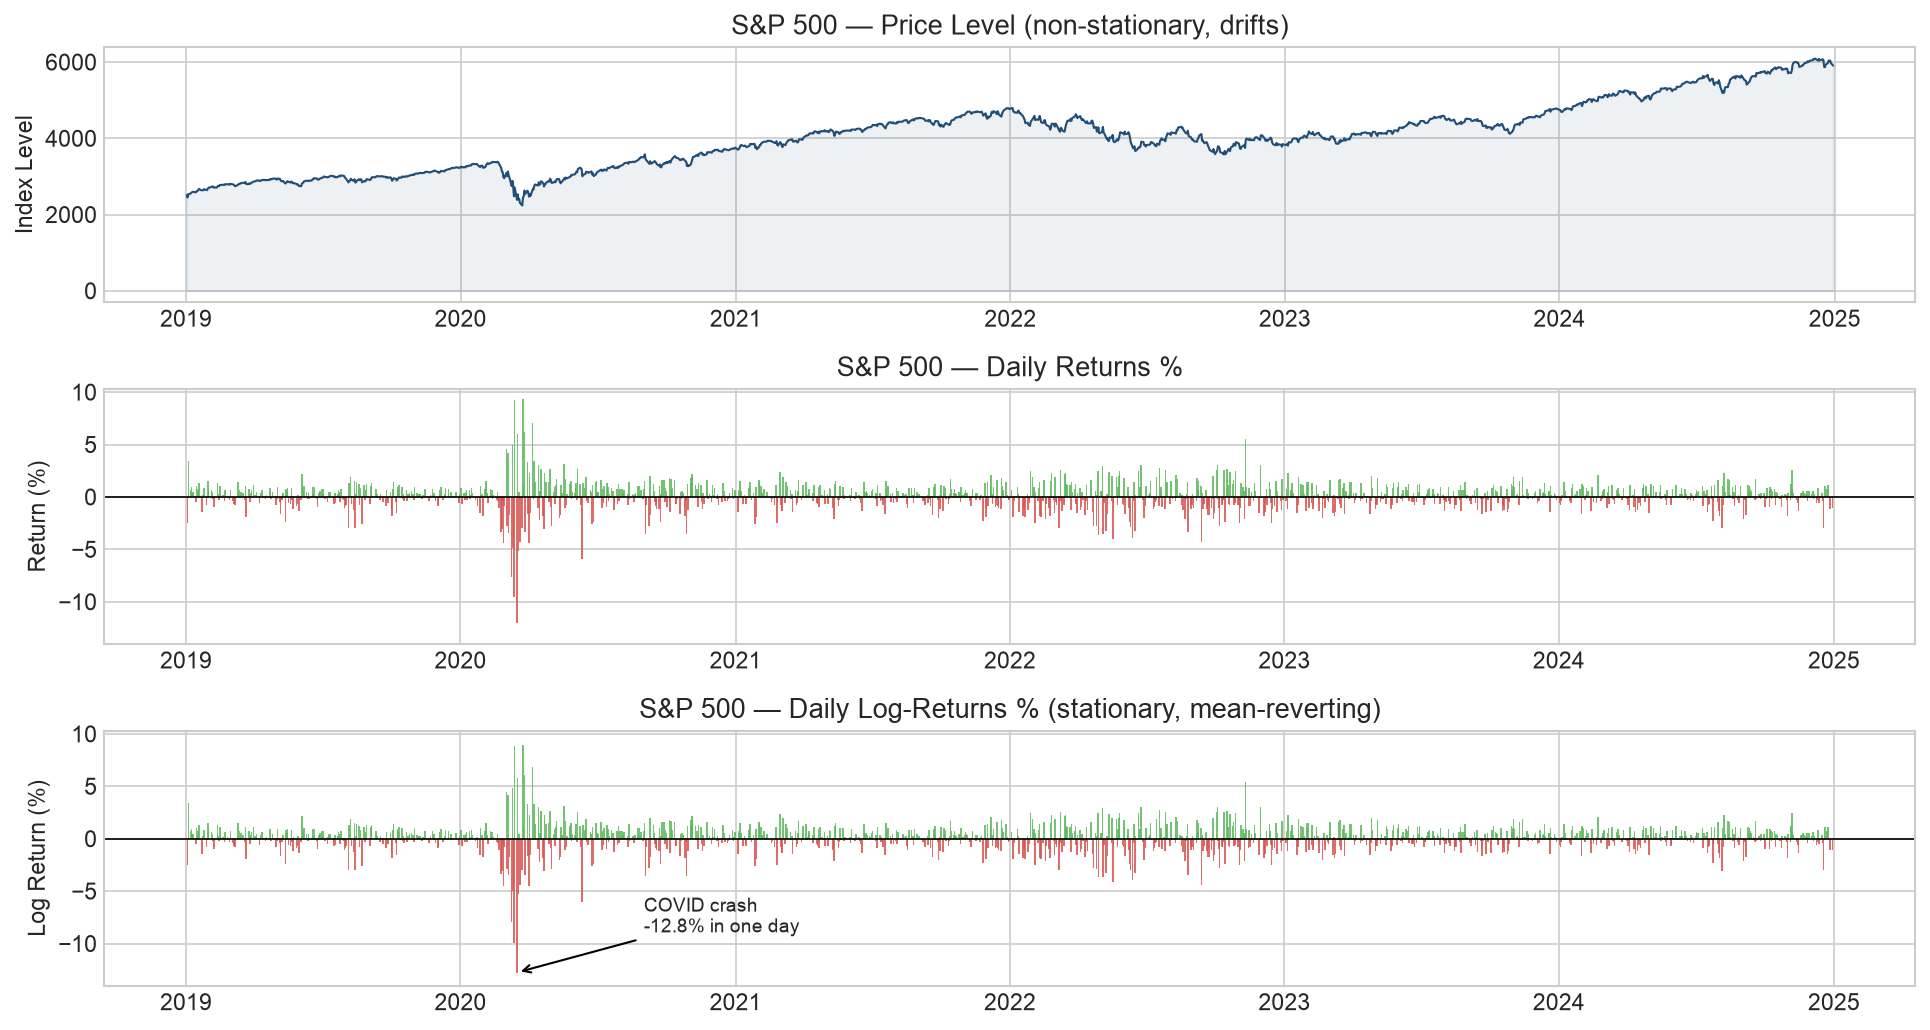

In [55]:
fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=False)

# Price level
axes[0].plot(prices.index, prices.values, color='#1f4e79', linewidth=1)
axes[0].set_title('S&P 500 — Price Level (non-stationary, drifts)')
axes[0].set_ylabel('Index Level')
axes[0].fill_between(prices.index, prices.values, alpha=0.08, color='#1f4e79')

# Force consistent, correct y-limits on both return panels (data-driven, not autoscale)
y_lo = min(ret.min(), log_ret.min()) * 1.1
y_hi = max(ret.max(), log_ret.max()) * 1.1

# Simple returns
colors = ['#d9534f' if r < 0 else '#5cb85c' for r in ret.values]
axes[1].bar(ret.index, ret.values, color=colors, width=2, alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('S&P 500 — Daily Returns %')
axes[1].set_ylabel('Return (%)')
axes[1].set_ylim(y_lo, y_hi)

# Log returns
colors = ['#d9534f' if r < 0 else '#5cb85c' for r in log_ret.values]
axes[2].bar(log_ret.index, log_ret.values, color=colors, width=2, alpha=0.85)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('S&P 500 — Daily Log-Returns % (stationary, mean-reverting)')
axes[2].set_ylabel('Log Return (%)')
axes[2].set_ylim(y_lo, y_hi)

# Annotate COVID
axes[2].annotate(f'COVID crash\n{log_ret.min():.1f}% in one day',
                 xy=(pd.Timestamp('2020-03-16'), log_ret.min()),
                 xytext=(pd.Timestamp('2020-09-01'), log_ret.min() * 0.7),
                 arrowprops=dict(arrowstyle='->', color='black'),
                 fontsize=9)

plt.tight_layout()

plt.show()


---
## Section 2 — Stylized Facts on Real Data

Part 1 described four empirical regularities that appear in virtually every financial return series. Here we verify all four on actual S&P 500 data (2019–2024).

| Fact | Name | What to look for |
|---|---|---|
| 1 | Returns look like random noise | Time series oscillates around zero — no exploitable trend |
| 2 | Fat tails (Leptokurtosis) | Histogram is taller and wider than a Normal distribution |
| 3 | Small autocorrelation in raw returns | ACF at most lags is inside the confidence band |
| 4 | Volatility clustering | Squared returns cluster — calm follows calm, volatile follows volatile |

The gap between Facts 3 and 4 is the entire reason GARCH exists: returns are unpredictable in direction but somewhat predictable in magnitude.

### Fact 1 — Returns Look Like Random Noise

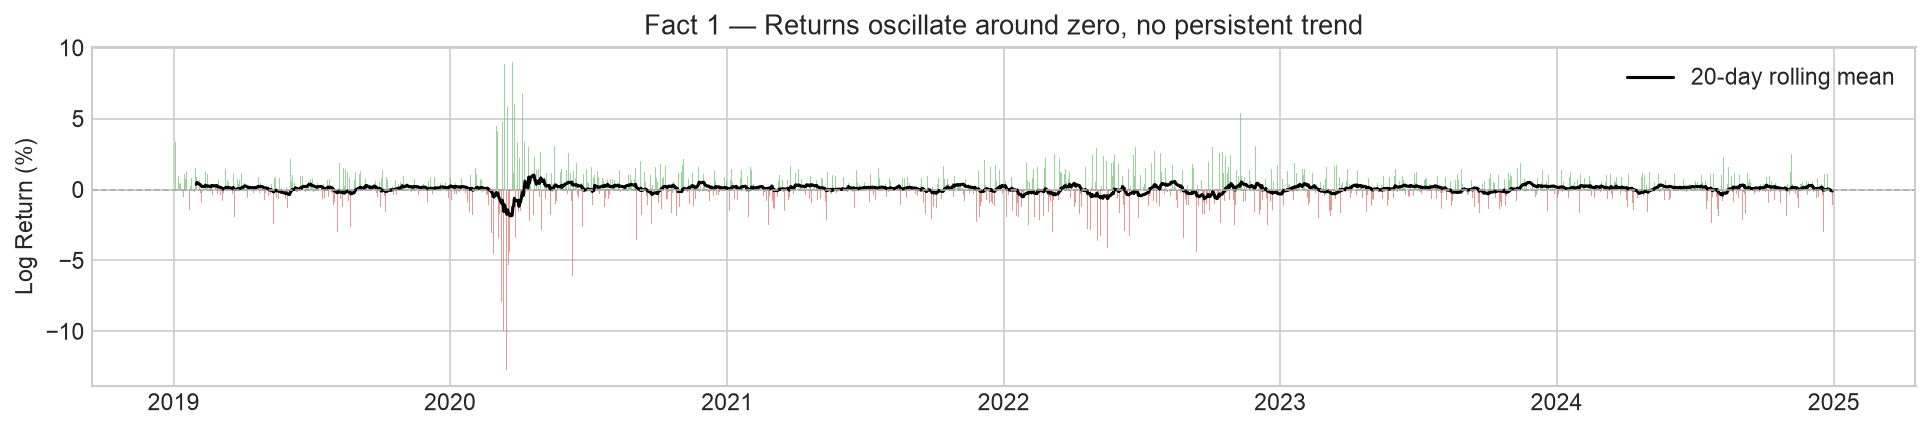

Overall mean return : 0.0568% per day
Max 20-day mean     : 1.014%
Min 20-day mean     : -1.851%
→ No persistent direction


In [56]:
# ── Fact 1: Returns look like random noise ──────────────────────────────────
rolling_mean = log_ret.rolling(20).mean()

fig, axes = plt.subplots(1, 1, figsize=(13, 3))

# Daily returns + rolling mean
colors = ['#d9534f' if r < 0 else '#5cb85c' for r in log_ret.values]
axes.bar(log_ret.index, log_ret.values, color=colors, width=1, alpha=0.6)
axes.plot(log_ret.index, rolling_mean, color='black', linewidth=1.5, label='20-day rolling mean')
axes.axhline(0, color='darkgray', linewidth=0.8, linestyle='--')
axes.set_title('Fact 1 — Returns oscillate around zero, no persistent trend')
axes.set_ylabel('Log Return (%)')
axes.legend()


plt.tight_layout()
plt.show()

print(f'Overall mean return : {log_ret.mean():.4f}% per day')
print(f'Max 20-day mean     : {rolling_mean.max():.3f}%')
print(f'Min 20-day mean     : {rolling_mean.min():.3f}%')
print('→ No persistent direction')

### Fact 2 — Fat Tails (Leptokurtosis)

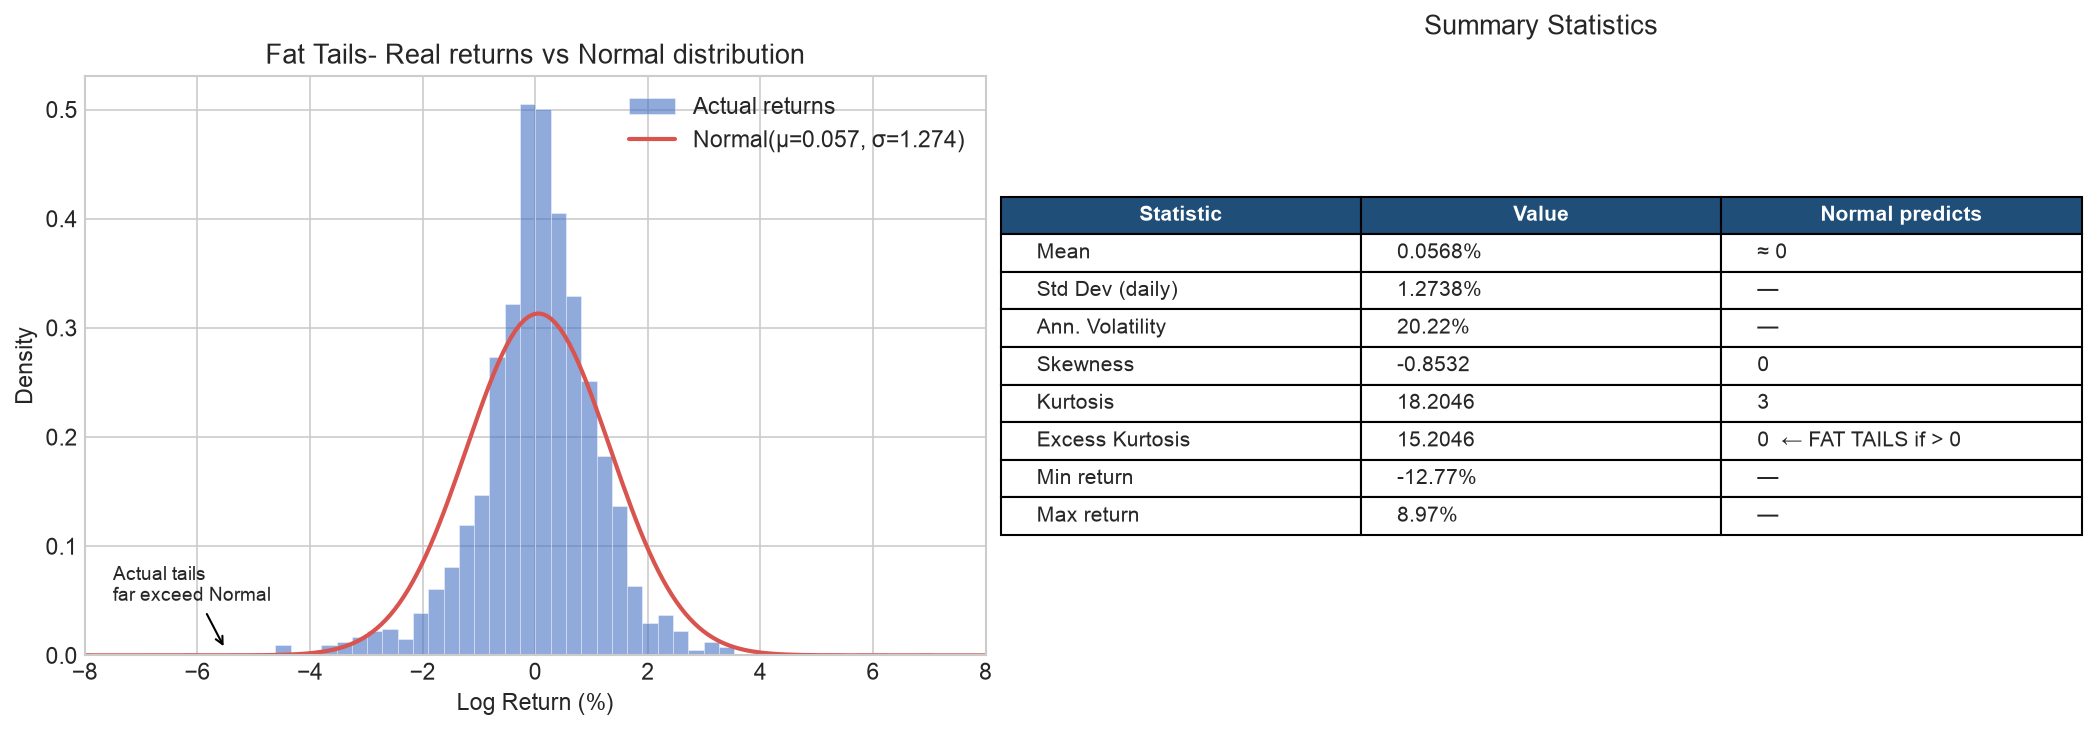

Excess kurtosis = 15.20  (Normal = 0)
Positive excess kurtosis means heavier tails and a sharper peak than Normal.
Extreme moves occur more often than Normal predicts — the fat tail problem.
Skewness = -0.853 → negative skew: large losses more common than large gains


In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Histogram vs Normal ────────────────────────────────────────────────
ax = axes[0]
mu, sigma = log_ret.mean(), log_ret.std()
x = np.linspace(log_ret.min() - 1, log_ret.max() + 1, 300)

ax.hist(log_ret, bins=80, density=True, color='#4472c4', alpha=0.6,
        label='Actual returns', edgecolor='white', linewidth=0.3)
ax.plot(x, norm.pdf(x, mu, sigma), color='#d9534f', linewidth=2,
        label=f'Normal(μ={mu:.3f}, σ={sigma:.3f})')

ax.set_xlabel('Log Return (%)')
ax.set_ylabel('Density')
ax.set_title('Fat Tails- Real returns vs Normal distribution')
ax.legend()
ax.set_xlim(-8, 8)

# Annotate: tails
ax.annotate('Actual tails\nfar exceed Normal', xy=(-5.5, 0.005),
            xytext=(-7.5, 0.05),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=9)

# ── Right: Summary statistics ────────────────────────────────────────────────
ax2 = axes[1]
ax2.axis('off')

skew  = stats.skew(log_ret)
kurt  = stats.kurtosis(log_ret, fisher=False)  # excess=False → Normal = 3
ekurt = stats.kurtosis(log_ret, fisher=True)    # excess →      Normal = 0

table_data = [
    ['Statistic', 'Value', 'Normal predicts'],
    ['Mean',            f'{mu:.4f}%',   '≈ 0'],
    ['Std Dev (daily)', f'{sigma:.4f}%', '—'],
    ['Ann. Volatility', f'{sigma*np.sqrt(252):.2f}%', '—'],
    ['Skewness',        f'{skew:.4f}',   '0'],
    ['Kurtosis',        f'{kurt:.4f}',   '3'],
    ['Excess Kurtosis', f'{ekurt:.4f}',  '0  ← FAT TAILS if > 0'],
    ['Min return',      f'{log_ret.min():.2f}%', '—'],
    ['Max return',      f'{log_ret.max():.2f}%', '—'],
]

tbl = ax2.table(cellText=table_data[1:], colLabels=table_data[0],
                loc='center', cellLoc='left')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.5)

for j in range(3):
    tbl[0, j].set_facecolor('#1f4e79')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

ax2.set_title('Summary Statistics', pad=20)

plt.tight_layout()
plt.show()

print(f'Excess kurtosis = {ekurt:.2f}  (Normal = 0)')
print(f'Positive excess kurtosis means heavier tails and a sharper peak than Normal.')
print(f'Extreme moves occur more often than Normal predicts — the fat tail problem.')
print(f'Skewness = {skew:.3f} → negative skew: large losses more common than large gains')

### Fact 3 — Small Autocorrelation in Raw Returns

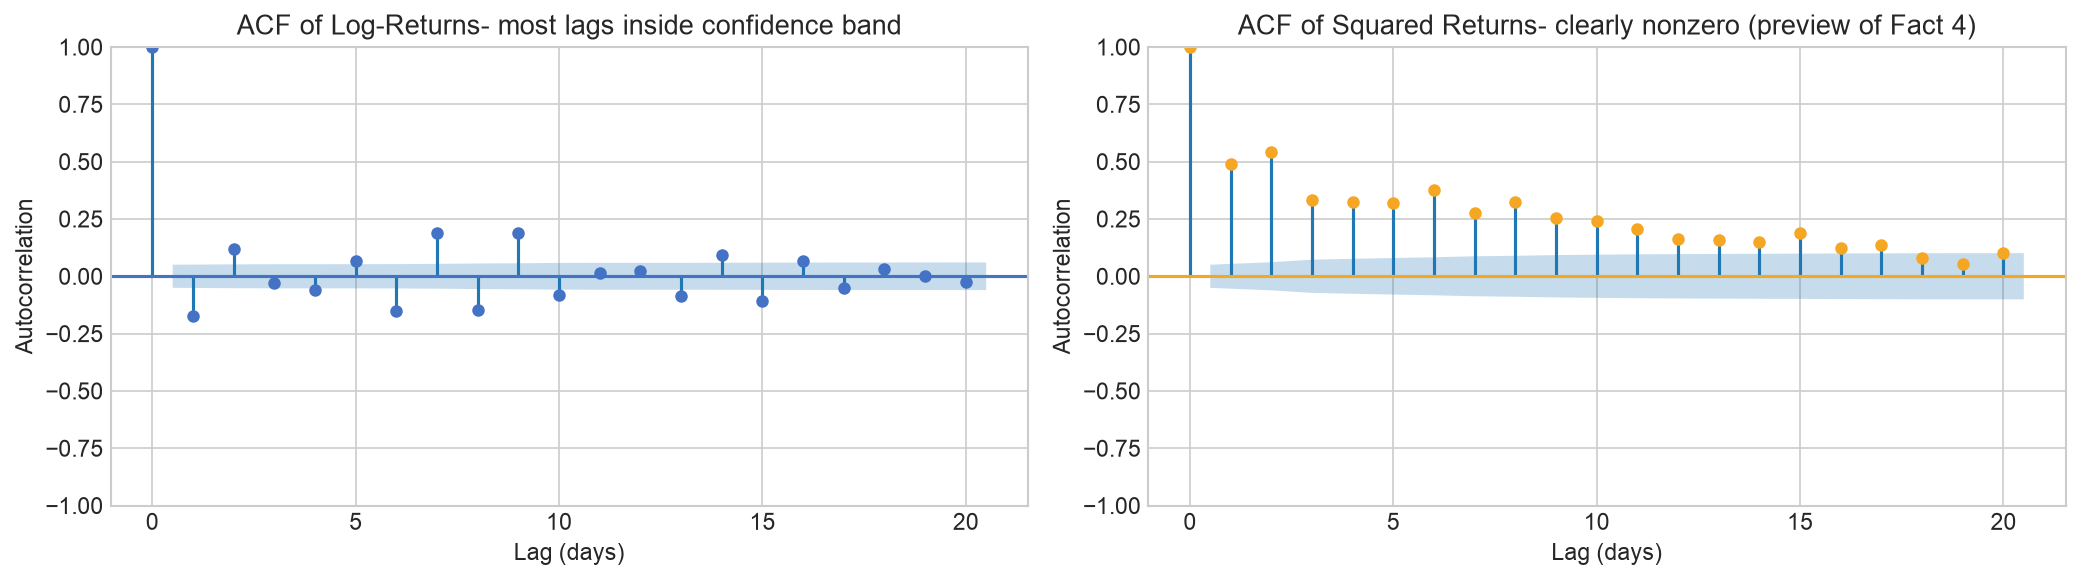

Lag-1 ACF (raw returns)    : -0.1739  →  R² = 3.02%
Lag-1 ACF (squared returns): 0.4887 →  R² = 23.88%

→ Raw returns: statistically detectable but R²<5% — direction barely predictable.
→ Squared returns: far more autocorrelated — magnitude IS predictable.
   This contrast is the core motivation for GARCH.


In [58]:
# ── Fact 3: Small autocorrelation in raw returns ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ACF of raw returns
plot_acf(log_ret, lags=20, ax=axes[0], alpha=0.05, color='#4472c4')
axes[0].set_title('ACF of Log-Returns- most lags inside confidence band')
axes[0].set_xlabel('Lag (days)')
axes[0].set_ylabel('Autocorrelation')

# ACF of squared returns (preview of Fact 4)
plot_acf(log_ret**2, lags=20, ax=axes[1], alpha=0.05, color='#f5a623')
axes[1].set_title('ACF of Squared Returns- clearly nonzero (preview of Fact 4)')
axes[1].set_xlabel('Lag (days)')
axes[1].set_ylabel('Autocorrelation')

plt.tight_layout()
plt.show()

lag1_raw = log_ret.autocorr(lag=1)
lag1_sq  = (log_ret**2).autocorr(lag=1)
r2_raw   = lag1_raw**2
r2_sq   = lag1_sq**2

print(f'Lag-1 ACF (raw returns)    : {lag1_raw:.4f}  →  R² = {r2_raw*100:.2f}%')
print(f'Lag-1 ACF (squared returns): {lag1_sq:.4f} →  R² = {r2_sq*100:.2f}%')
print()
print('→ Raw returns: statistically detectable but R²<5% — direction barely predictable.')
print('→ Squared returns: far more autocorrelated — magnitude IS predictable.')
print('   This contrast is the core motivation for GARCH.')

### Fact 4 — Volatility Clustering

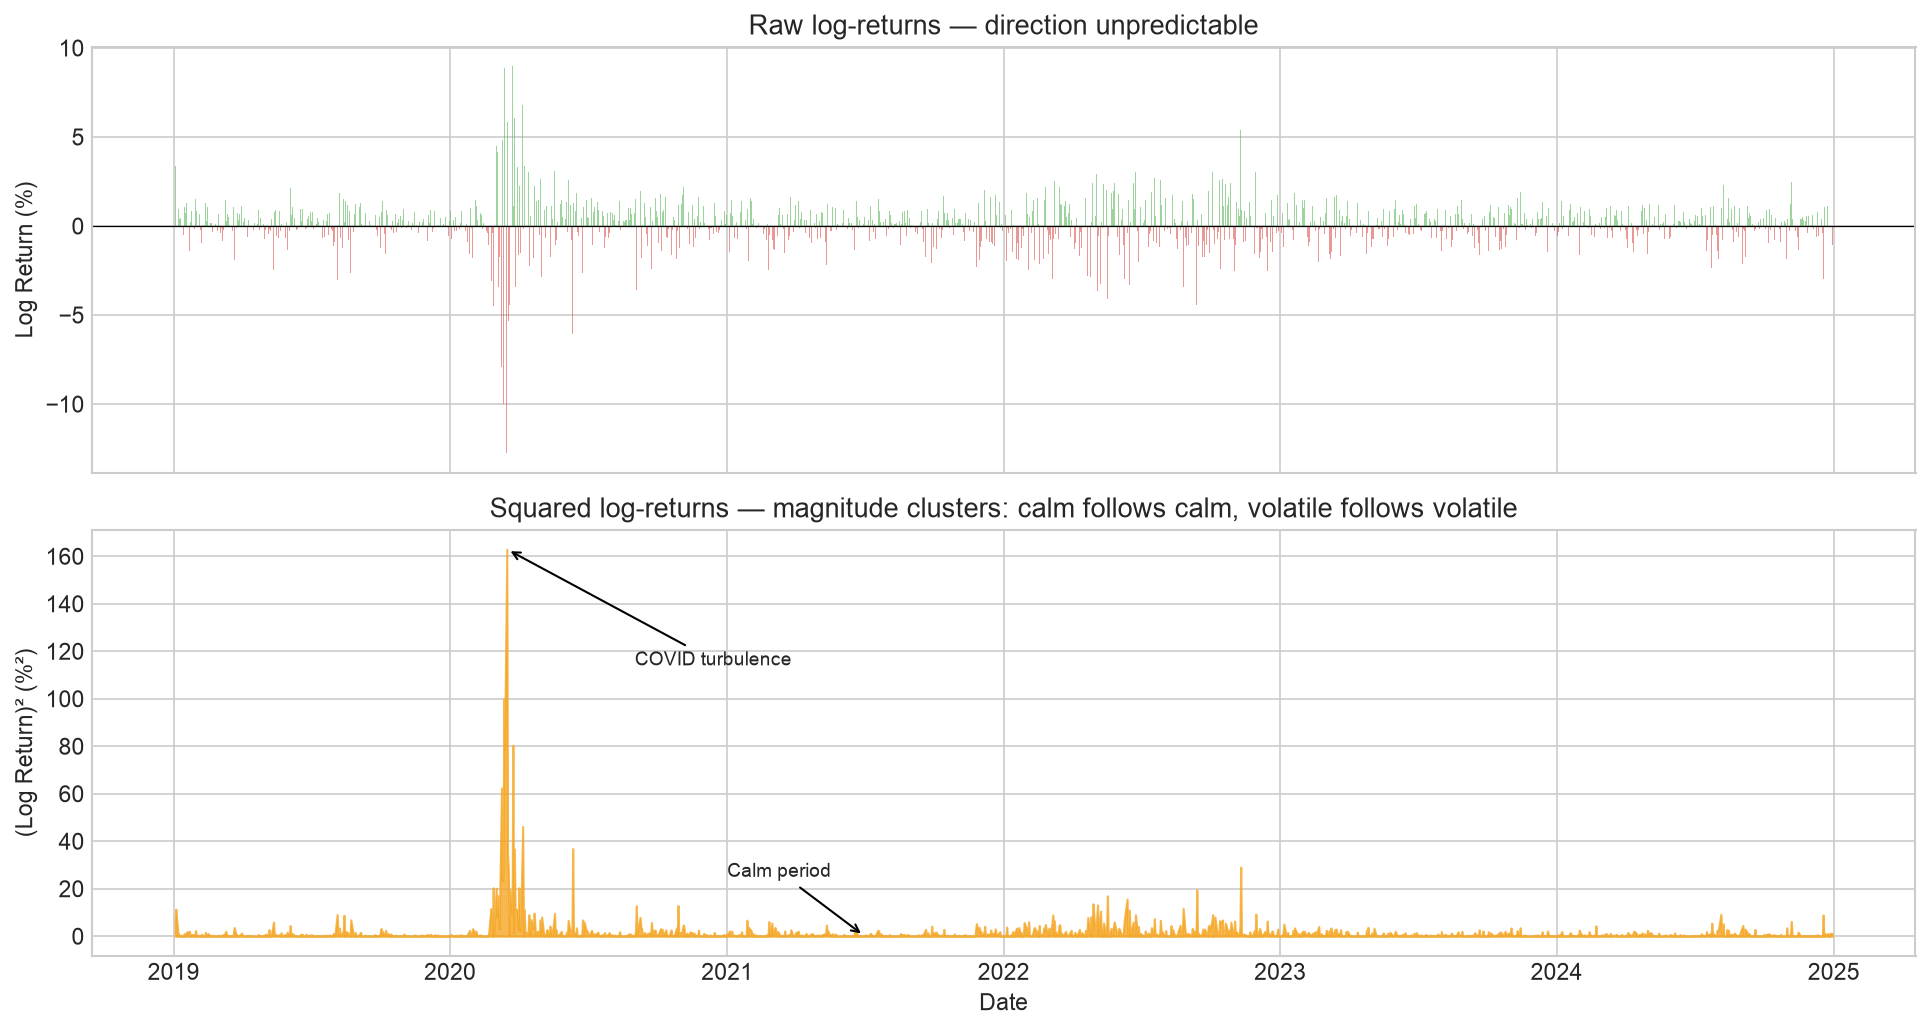

Min 20-day annualized vol  : 5.0%
Max 20-day annualized vol  : 97.9%
Ratio (max/min)            : 19.7×

→ Volatility swings by more than 10× — it is not constant.
→ If volatility is predictable, so is risk. That is what GARCH captures.


In [59]:
# ── Fact 4: Volatility clustering ────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# Raw returns (direction)
colors = ['#d9534f' if r < 0 else '#5cb85c' for r in log_ret.values]
axes[0].bar(log_ret.index, log_ret.values, color=colors, width=1, alpha=0.6)
axes[0].axhline(0, color='black', linewidth=0.6)
axes[0].set_title('Raw log-returns — direction unpredictable')
axes[0].set_ylabel('Log Return (%)')

# Squared returns (magnitude clustering)
axes[1].fill_between(log_ret.index, log_ret.values**2, color='#f5a623', alpha=0.8)
axes[1].set_title('Squared log-returns — magnitude clusters: calm follows calm, volatile follows volatile')
axes[1].set_ylabel('(Log Return)² (%²)')
axes[1].set_xlabel('Date')

# Annotate quiet and turbulent periods
axes[1].annotate('COVID turbulence', xy=(pd.Timestamp('2020-03-16'), (log_ret.min())**2),
                 xytext=(pd.Timestamp('2020-09-01'), (log_ret.min())**2 * 0.7),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=9)

axes[1].annotate('Calm period', xy=(pd.Timestamp('2021-07-01'), 0.15),
                 xytext=(pd.Timestamp('2021-01-01'), 25),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=9)

plt.tight_layout()
plt.show()

# Rolling std to quantify clustering
roll_vol = log_ret.rolling(20).std() * np.sqrt(252)
print(f'Min 20-day annualized vol  : {roll_vol.min():.1f}%')
print(f'Max 20-day annualized vol  : {roll_vol.max():.1f}%')
print(f'Ratio (max/min)            : {roll_vol.max()/roll_vol.min():.1f}×')
print()
print('→ Volatility swings by more than 10× — it is not constant.')
print('→ If volatility is predictable, so is risk. That is what GARCH captures.')

---
## Section 3 — Stationarity: The ADF Test

In Part 1 we showed *visually* that prices drift and returns don't. Now we test it formally.

The **Augmented Dickey-Fuller (ADF) test** tests the null hypothesis:

> H₀: The series has a unit root (is non-stationary)

**Reject H₀** (p < 0.05) → stationary.  
**Fail to reject** (p ≥ 0.05) → non-stationary — do not model directly.

We expect: prices → fail to reject, log-returns → reject strongly.

In [60]:
def run_adf(series, name):
    result = adfuller(series.dropna(), autolag='AIC')
    stat, pval, lags, nobs, crit_vals, _ = result
    verdict = 'STATIONARY ✓' if pval < 0.05 else 'NON-STATIONARY ✗'
    print(f'--- ADF Test: {name} ---')
    print(f'  ADF Statistic : {stat:.4f}')
    print(f'  p-value       : {pval:.6f}')
    print(f'  Lags used     : {lags}')
    print(f'  Critical vals : 1%={crit_vals["1%"]:.3f}  5%={crit_vals["5%"]:.3f}  10%={crit_vals["10%"]:.3f}')
    print(f'  Verdict       : {verdict}')
    print()
    return pval

# Test both
pval_price  = run_adf(prices,   'S&P 500 Price Level')
pval_return = run_adf(log_ret,  'S&P 500 Log-Returns')

print('Interpretation:')
print('  Prices: p-value is large → we cannot reject the unit root → prices are non-stationary.')
print('  Returns: p-value ≈ 0 → strongly reject unit root → log-returns are stationary.')
print('  This is why every model in this notebook runs on log-returns, not prices.')

--- ADF Test: S&P 500 Price Level ---
  ADF Statistic : -0.4175
  p-value       : 0.907137
  Lags used     : 10
  Critical vals : 1%=-3.435  5%=-2.863  10%=-2.568
  Verdict       : NON-STATIONARY ✗

--- ADF Test: S&P 500 Log-Returns ---
  ADF Statistic : -11.5994
  p-value       : 0.000000
  Lags used     : 9
  Critical vals : 1%=-3.435  5%=-2.863  10%=-2.568
  Verdict       : STATIONARY ✓

Interpretation:
  Prices: p-value is large → we cannot reject the unit root → prices are non-stationary.
  Returns: p-value ≈ 0 → strongly reject unit root → log-returns are stationary.
  This is why every model in this notebook runs on log-returns, not prices.


---
## Section 4 — ACF and PACF

**ACF (lag k)** = correlation between today's return and the return k days ago. If day 1 influences day 2, and day 2 influences day 3, then day 1 and day 3 look correlated even with no direct link — the effect leaks through the middleman.

**PACF (lag k)** = same correlation, but with the effect of every day in between removed. It isolates only the *direct* link at each lag.

**One-line summary:** ACF = total correlation. PACF = correlation with the middleman stripped out.

**Why we care — the Box-Jenkins rule:**

| Pattern | Suggests |
|---|---|
| ACF cuts off after lag q; PACF decays | MA(q) |
| PACF cuts off after lag p; ACF decays | AR(p) |
| Both decay gradually | ARMA(p,q) — need information criteria |
| Both near zero | White noise — nothing to model |

The *shape* of the two plots tells us what kind of model, if any, fits the returns.

We plot three things below: ACF of raw returns, PACF of raw returns, and ACF of *squared* returns (the volatility clustering signal from Part 1).

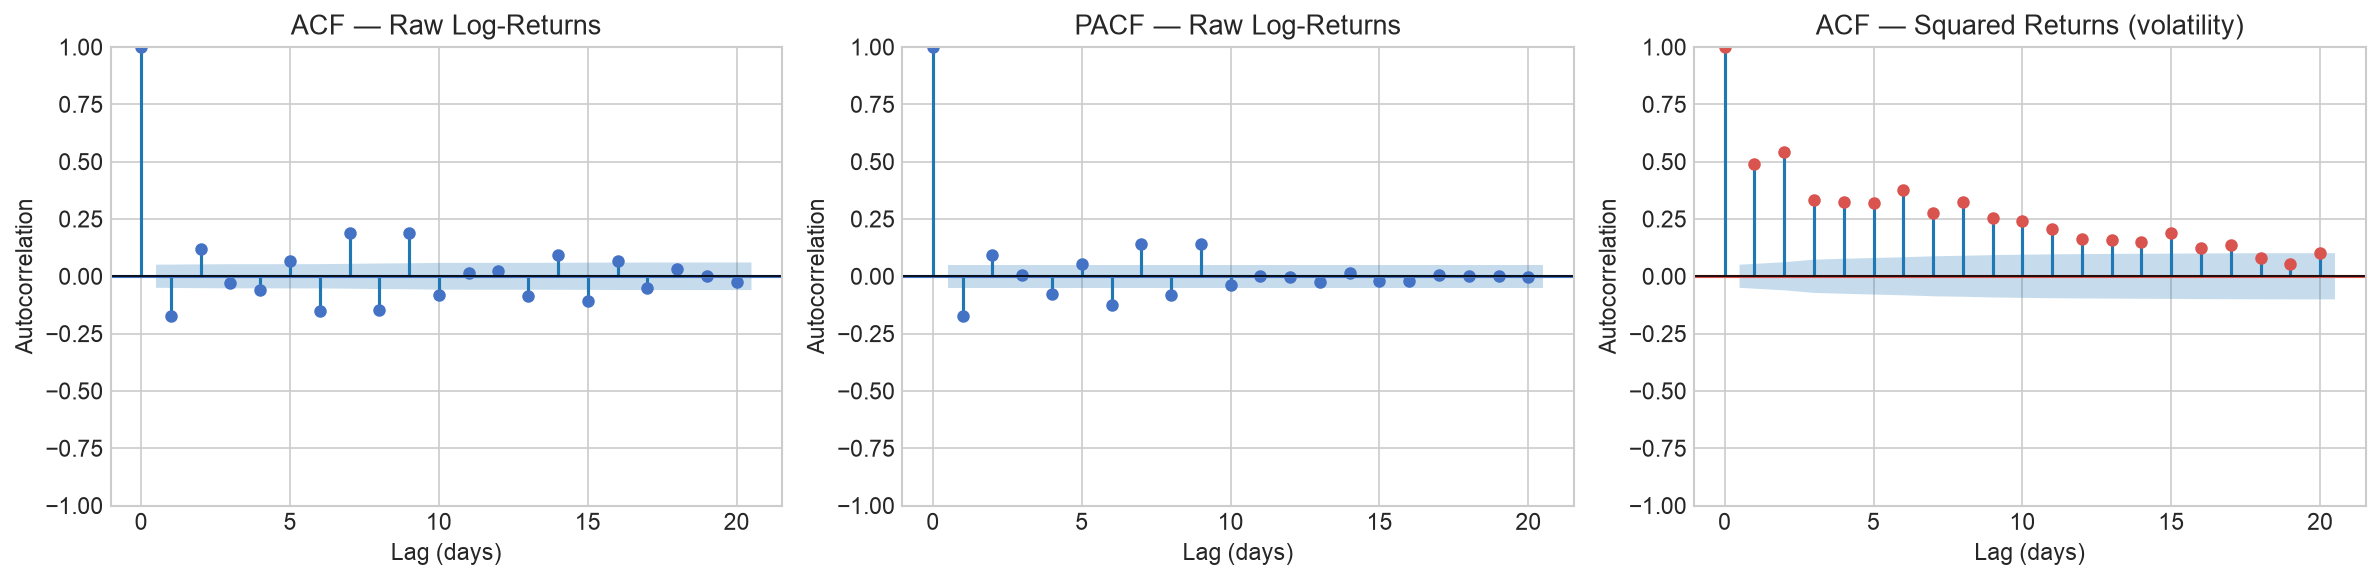

Lag    ACF (returns)      PACF (returns)     ACF (squared)     
--------------------------------------------------------------
1      -0.1736            -0.1736            0.4886 ← CLUSTERING
2      0.1188             0.0914             0.5418 ← CLUSTERING
3      -0.0288            0.0060             0.3340 ← CLUSTERING
4      -0.0587            -0.0761            0.3235 ← CLUSTERING
5      0.0686             0.0520             0.3211 ← CLUSTERING

Reading the plots:
  ACF/PACF of raw returns: nearly all bars inside the blue confidence bands → little mean structure
  ACF of squared returns: bars outside the bands at many lags → strong volatility clustering
  This contrast is the justification for GARCH 

Which model fits best?
--------------------------------------------------------------
  Mean equation: some ACF/PACF bars are outside the confidence bands
  → a small ARMA(p,q) mean model may be worth fitting; use AIC/BIC to pick p, q.

  Variance equation: ACF of squared returns has b

In [61]:
N_LAGS = 20

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ACF — raw returns
plot_acf(log_ret, lags=N_LAGS, ax=axes[0], alpha=0.05,
         title='ACF — Raw Log-Returns', color='#4472c4')
axes[0].set_xlabel('Lag (days)')

# PACF — raw returns  
plot_pacf(log_ret, lags=N_LAGS, ax=axes[1], alpha=0.05,
          title='PACF — Raw Log-Returns', method='ywm', color='#4472c4')
axes[1].set_xlabel('Lag (days)')

# ACF — squared returns (volatility clustering)
plot_acf(log_ret**2, lags=N_LAGS, ax=axes[2], alpha=0.05,
         title='ACF — Squared Returns (volatility)', color='#d9534f')
axes[2].set_xlabel('Lag (days)')

for ax in axes:
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel('Autocorrelation')

plt.tight_layout()
plt.show()

# Print the actual ACF/PACF values at lag 1-5
acf_vals  = acf(log_ret,  nlags=5, fft=True)[1:]
pacf_vals = pacf(log_ret, nlags=5, method='ywm')[1:]
acf_sq    = acf(log_ret**2, nlags=5, fft=True)[1:]

print(f'{"Lag":<6} {"ACF (returns)":<18} {"PACF (returns)":<18} {"ACF (squared)":<18}')
print('-' * 62)
for i, (a, p, s) in enumerate(zip(acf_vals, pacf_vals, acf_sq), 1):
    flag = ' ← CLUSTERING' if abs(s) > 0.1 else ''
    print(f'{i:<6} {a:<18.4f} {p:<18.4f} {s:.4f}{flag}')

print()
print('Reading the plots:')
print('  ACF/PACF of raw returns: nearly all bars inside the blue confidence bands → little mean structure')
print('  ACF of squared returns: bars outside the bands at many lags → strong volatility clustering')
print('  This contrast is the justification for GARCH ')

print()
print('Which model fits best?')
print('-' * 62)

mean_flat  = all(abs(v) < 0.1 for v in acf_vals) and all(abs(v) < 0.1 for v in pacf_vals)
vol_signal = any(abs(v) > 0.1 for v in acf_sq)

if mean_flat:
    print('  Mean equation: ACF and PACF of raw returns are both ~near zero at every lag')
    print('  → no meaningful autocorrelation to model. Raw returns behave like white noise,')
    print('    so a plain AR/MA/ARMA model on the returns themselves is not justified.')
    print('    Use a simple constant (or zero) mean, e.g. an ARMA(0,0)/white-noise mean model.')
else:
    print('  Mean equation: some ACF/PACF bars are outside the confidence bands')
    print('  → a small ARMA(p,q) mean model may be worth fitting; use AIC/BIC to pick p, q.')

print()
if vol_signal:
    print('  Variance equation: ACF of squared returns has bars outside the confidence bands')
    print('  → strong volatility clustering (variance is autocorrelated even though returns are not).')
    print('    Best model: GARCH(1,1) (or an asymmetric variant like GJR-GARCH/EGARCH if leverage')
    print('    effects are suspected), fit on top of the near-white-noise mean equation above.')
else:
    print('  Variance equation: squared returns show little autocorrelation → no strong clustering.')
    print('    A constant-variance model is likely adequate; GARCH may not be needed.')

print()
print('Overall recommendation:')
print('  Mean:     ARMA(0,0) / constant mean  (raw returns ≈ white noise)' if mean_flat else '  Mean:     ARMA(p,q) — select p,q via AIC/BIC')
print('  Variance: GARCH(1,1)(squared returns show clustering)' if vol_signal else '  Variance: constant variance')


---
## Section 5 — ARIMA Order Selection

AIC and BIC grid search across all ARIMA(p,0,q) combinations (p,q ∈ {0..3}) selects **ARIMA(1,0,1)** on this data. The scores across all models are narrow, confirming Stylized Fact 3: daily return mean structure is minimal. (not shown in this notebook to keep it focused on the models)

---
## Section 6 — Fit ARIMA(1,0,1) and Check Residuals

We fit the selected model and run **residual diagnostics** — the check that determines whether ARIMA is enough or whether GARCH is needed.

**ARIMA(1,0,1) model:**
$$r_t = c + \phi_1 r_{t-1} + \varepsilon_t + \theta_1 \varepsilon_{t-1}$$

- **c**: constant (long-run average return)
- **φ₁** (phi): AR(1) term — weight on yesterday's return
- **θ₁** (theta): MA(1) term — weight on yesterday's shock
- **ε_t**: white noise error at time t
- **Condition:** |φ₁| < 1 for stationarity (already satisfied — log-returns are stationary)

Parameters are estimated by Maximum Likelihood (out of scope for this notebook).

**What good residuals look like:**
- ACF of residuals: all inside the confidence bands (white noise in the mean)
- ACF of **squared** residuals: still outside the bands — ARCH effects remain

That second point is what forces us to GARCH.

In [62]:
# ARIMA(1,0,1) — order selected by AIC/BIC 
best_p, best_q = 1, 1

print(f'Fitting ARIMA({best_p},0,{best_q})...')
arima_model  = ARIMA(log_ret, order=(best_p, 0, best_q))
arima_fitted = arima_model.fit()

print(arima_fitted.summary())


Fitting ARIMA(1,0,1)...
                               SARIMAX Results                                
Dep. Variable:         Log Return (%)   No. Observations:                 1508
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -2476.931
Date:                Sun, 12 Jul 2026   AIC                           4961.862
Time:                        20:33:26   BIC                           4983.136
Sample:                             0   HQIC                          4969.786
                               - 1508                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0571      0.030      1.879      0.060      -0.002       0.117
ar.L1         -0.4539      0.046     -9.880      0.000      -0.544      -0.364
ma.L1          0.2824      0

In [63]:

residuals   = arima_fitted.resid
fitted_vals = arima_fitted.fittedvalues

ss_res = np.sum(residuals**2) #leftover error the model could not explain
ss_tot = np.sum((log_ret - log_ret.mean())**2) #total variance in actual returns
r2 = 1 - ss_res / ss_tot
print(f'\nIn-sample R² = {r2:.4f}  ({r2*100:.2f}%)')
print('ARIMA explains almost none of return variance — consistent with near-zero autocorrelation.')


In-sample R² = 0.0355  (3.55%)
ARIMA explains almost none of return variance — consistent with near-zero autocorrelation.


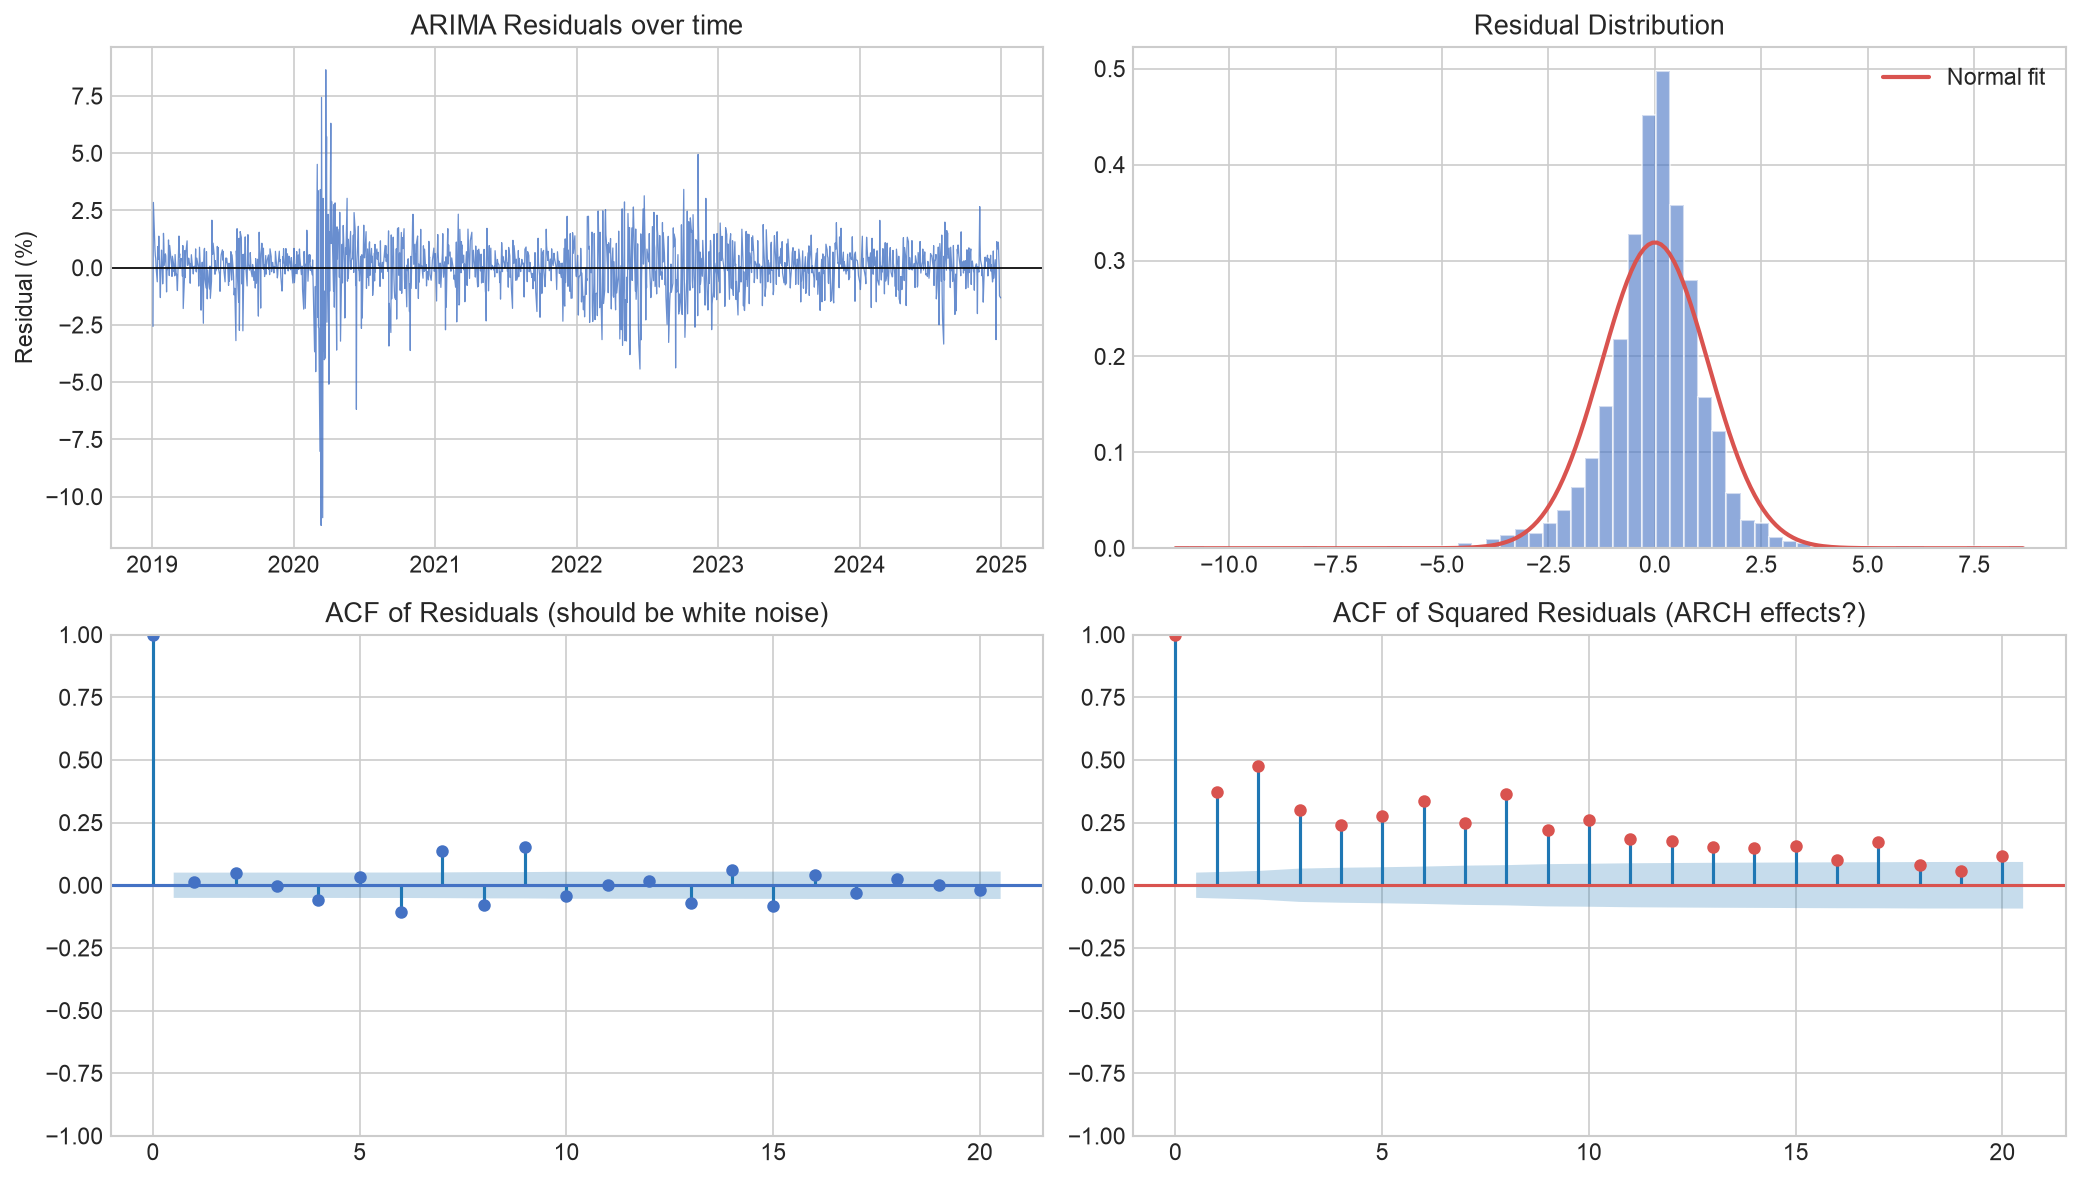

Ljung-Box test on residuals (H₀: no autocorrelation):
  Lag 10 p-value: 0.0000  → autocorrelation remains ✗

Ljung-Box test on squared residuals (H₀: no ARCH effects):
  Lag 10 p-value: 0.000000  → ARCH effects present ✗ — GARCH needed

ARCH-LM test on residuals (H₀: no ARCH effects):
  LM stat: 432.1198   p-value: 0.000000  → ARCH effects present — GARCH is necessary


In [64]:
# ── Residual diagnostics ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1. Residuals over time
axes[0, 0].plot(residuals.index, residuals.values, color='#4472c4', linewidth=0.6, alpha=0.8)
axes[0, 0].axhline(0, color='black', linewidth=0.8)
axes[0, 0].set_title('ARIMA Residuals over time')
axes[0, 0].set_ylabel('Residual (%)')

# 2. Residual histogram
axes[0, 1].hist(residuals, bins=60, density=True, color='#4472c4', alpha=0.6, edgecolor='white')
x_r = np.linspace(residuals.min(), residuals.max(), 200)
axes[0, 1].plot(x_r, norm.pdf(x_r, residuals.mean(), residuals.std()),
                color='#d9534f', linewidth=2, label='Normal fit')
axes[0, 1].set_title('Residual Distribution')
axes[0, 1].legend()

# 3. ACF of residuals
plot_acf(residuals, lags=20, ax=axes[1, 0], alpha=0.05,
         title='ACF of Residuals (should be white noise)', color='#4472c4')

# 4. ACF of squared residuals — ARCH test
plot_acf(residuals**2, lags=20, ax=axes[1, 1], alpha=0.05,
         title='ACF of Squared Residuals (ARCH effects?)', color='#d9534f')

plt.tight_layout()
plt.show()

# ── Ljung-Box and ARCH-LM tests ───────────────────────────────────────────────
lb_resid = acorr_ljungbox(residuals,   lags=10, return_df=True)
lb_sq    = acorr_ljungbox(residuals**2, lags=10, return_df=True)
arch_lm  = het_arch(residuals, nlags=5)

print('Ljung-Box test on residuals (H₀: no autocorrelation):')
print(f'  Lag 10 p-value: {lb_resid["lb_pvalue"].iloc[-1]:.4f}', end='  ')
print('→ white noise ✓' if lb_resid['lb_pvalue'].iloc[-1] > 0.05 else '→ autocorrelation remains ✗')

print('\nLjung-Box test on squared residuals (H₀: no ARCH effects):')
print(f'  Lag 10 p-value: {lb_sq["lb_pvalue"].iloc[-1]:.6f}', end='  ')
print('→ no ARCH ✓' if lb_sq['lb_pvalue'].iloc[-1] > 0.05 else '→ ARCH effects present ✗ — GARCH needed')

print(f'\nARCH-LM test on residuals (H₀: no ARCH effects):')
print(f'  LM stat: {arch_lm[0]:.4f}   p-value: {arch_lm[1]:.6f}', end='  ')
print('→ ARCH effects present — GARCH is necessary' if arch_lm[1] < 0.05 else '→ no ARCH effects')

---
## Section 7 — GARCH(1,1)

The residual diagnostics above show ARCH effects in the squared residuals. ARIMA cannot model variance clustering — GARCH can.

**GARCH(1,1) model:**
$$\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2$$

- **ω** (omega): long-run variance floor
- **α** (alpha): weight on yesterday's squared shock — how fast variance reacts
- **β** (beta): weight on yesterday's variance — how persistent shocks are
- **Condition:** α + β < 1 for stationarity

Parameters are estimated by Maximum Likelihood (out of scope for this notebook). 

In [65]:
# ── Fit GARCH(1,1) ───────────────────────────────────────────────────────────
garch_spec = arch_model(
    log_ret,
    vol  = 'Garch',   # GARCH variance process
    p    = 1,          # lags of squared returns (alpha terms)
    q    = 1,          # lags of variance (beta terms)
    dist = 'Normal',   # normal innovations
    mean = 'Constant'  # constant mean term
)

garch_fit = garch_spec.fit(disp='off')
print(garch_fit.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:         Log Return (%)   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2107.80
Distribution:                  Normal   AIC:                           4223.60
Method:            Maximum Likelihood   BIC:                           4244.88
                                        No. Observations:                 1508
Date:                Sun, Jul 12 2026   Df Residuals:                     1507
Time:                        20:33:26   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0947  2.155e-02      4.396  1.101e-05 [5.250e-0

GARCH mean-equation R² = -0.0009  (-0.09%)
  Near zero, same as ARIMA - GARCH mean model is just a constant, it is not built to predict direction.
GARCH variance-equation R² = 0.3112  (31.12%)
  This is the number that matters — it is the variance-clustering signal ARIMA could not touch.


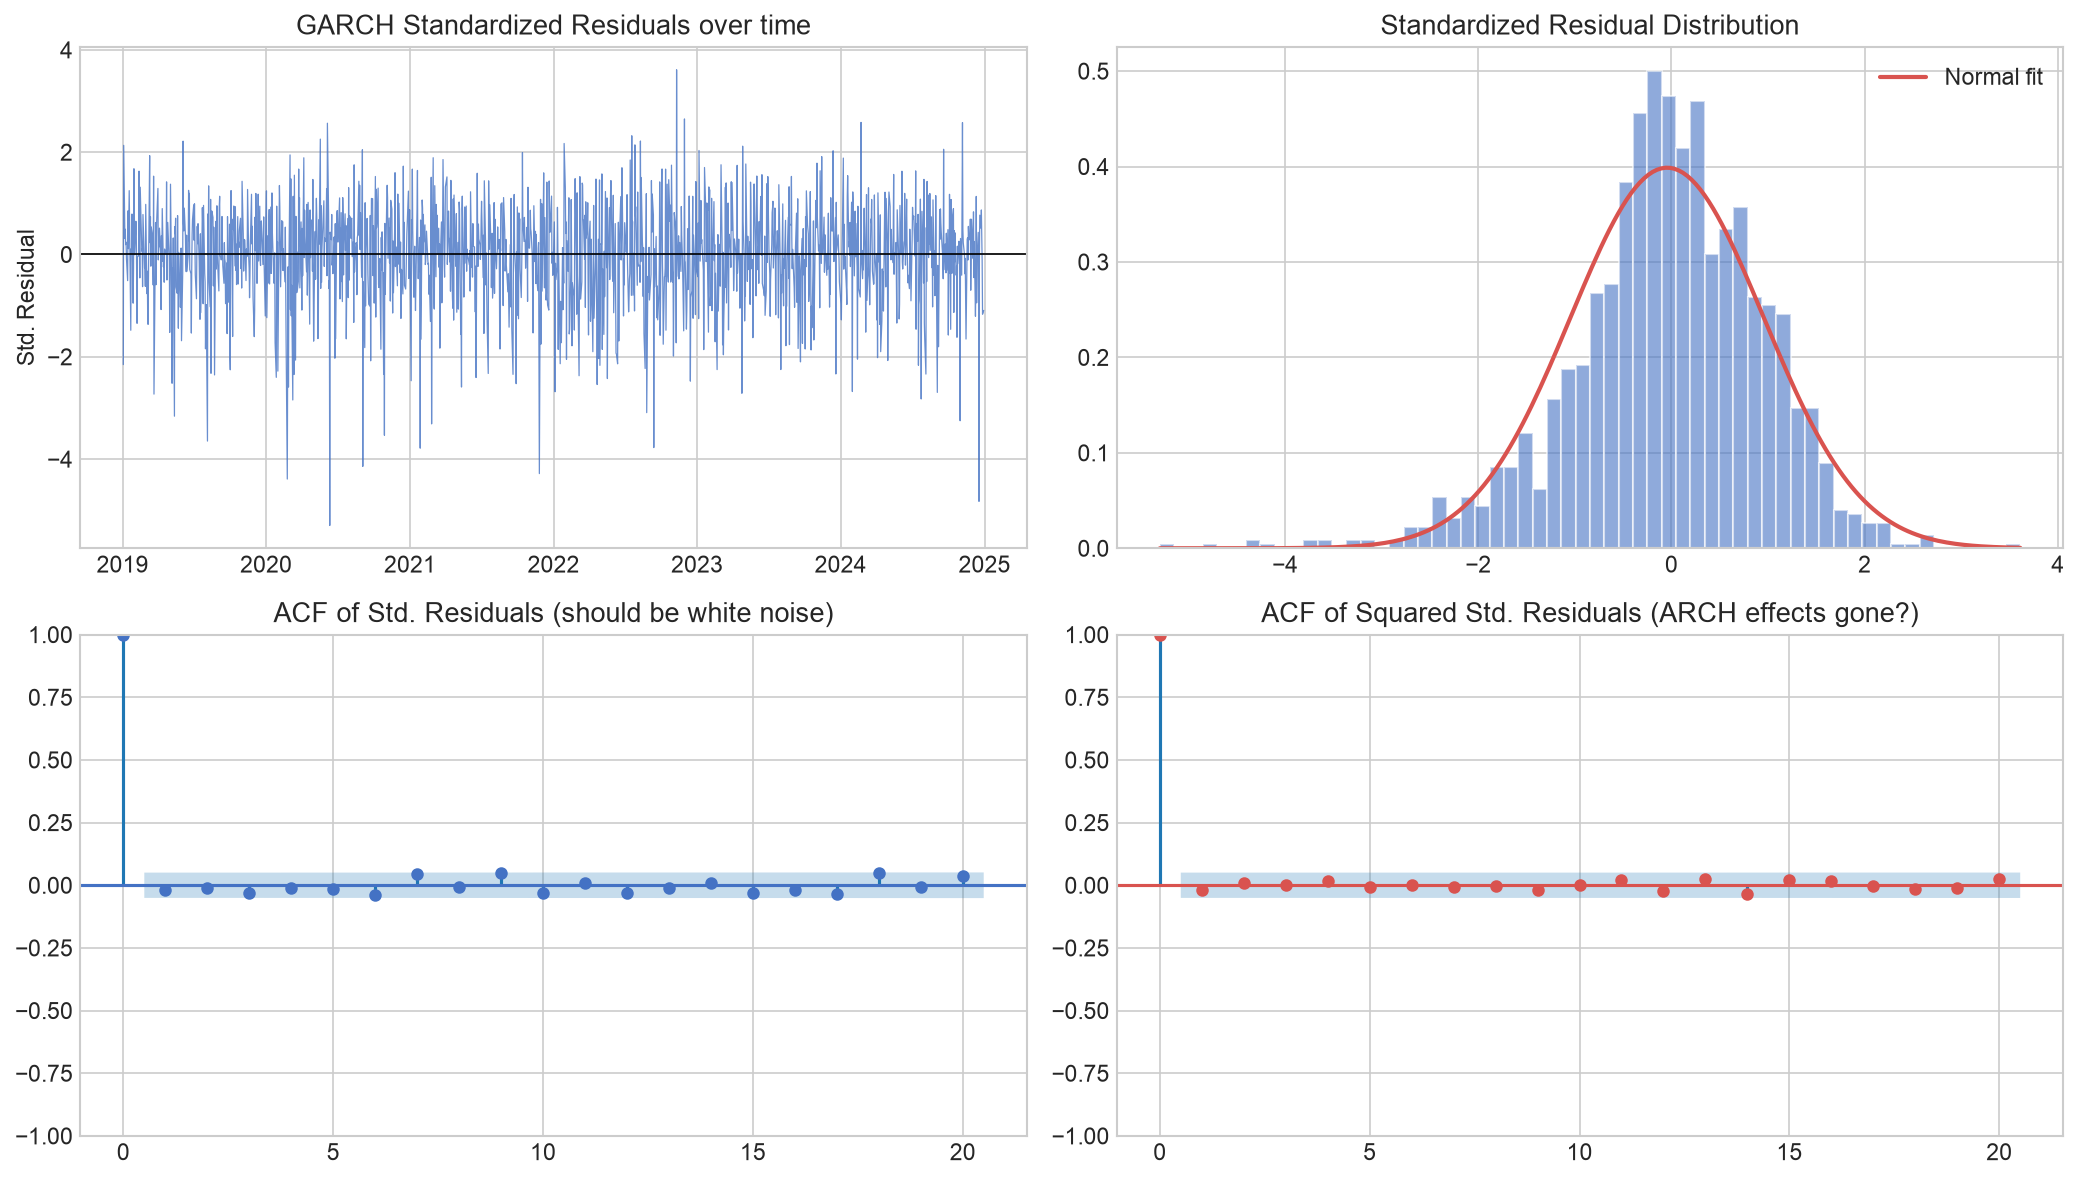

Ljung-Box test on standardized residuals (H₀: no autocorrelation):
  Lag 10 p-value: 0.2016  → white noise ✓

Ljung-Box test on squared standardized residuals (H₀: no remaining ARCH effects):
  Lag 10 p-value: 0.997507  → ARCH effects captured ✓

ARCH-LM test on standardized residuals (H₀: no remaining ARCH effects):
  LM stat: 1.3697   p-value: 0.927601  → ARCH effects captured ✓

Model comparison (lower is better):
  ARIMA(1,0,1)  AIC = 4961.86   BIC = 4983.14
  GARCH(1,1)    AIC = 4223.60   BIC = 4244.88
  GARCH wins on both — modeling the variance, not just the mean, fits the data far better.


In [66]:
# ── GARCH residual diagnostics ───────
std_resid = garch_fit.std_resid.dropna()  # standardized residuals: (r_t - mu) / sigma_t

# Mean-equation R² (same definition as the ARIMA R² above)
garch_mean_resid = garch_fit.resid.dropna()
ss_res_mean = np.sum(garch_mean_resid**2)
ss_tot_mean = np.sum((log_ret.loc[garch_mean_resid.index] - log_ret.loc[garch_mean_resid.index].mean())**2)
r2_mean = 1 - ss_res_mean / ss_tot_mean
print(f'GARCH mean-equation R² = {r2_mean:.4f}  ({r2_mean*100:.2f}%)')
print("  Near zero, same as ARIMA - GARCH mean model is just a constant, it is not built to predict direction.")

# Variance-equation R²: how much of the squared-residual variance the conditional variance explains
cond_var = garch_fit.conditional_volatility.loc[garch_mean_resid.index]**2
sq_resid = garch_mean_resid**2
ss_res_var = np.sum((sq_resid - cond_var)**2)
ss_tot_var = np.sum((sq_resid - sq_resid.mean())**2)
r2_var = 1 - ss_res_var / ss_tot_var
print(f'GARCH variance-equation R² = {r2_var:.4f}  ({r2_var*100:.2f}%)')
print('  This is the number that matters — it is the variance-clustering signal ARIMA could not touch.')

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1. Standardized residuals over time
axes[0, 0].plot(std_resid.index, std_resid.values, color='#4472c4', linewidth=0.6, alpha=0.8)
axes[0, 0].axhline(0, color='black', linewidth=0.8)
axes[0, 0].set_title('GARCH Standardized Residuals over time')
axes[0, 0].set_ylabel('Std. Residual')

# 2. Standardized residual histogram
axes[0, 1].hist(std_resid, bins=60, density=True, color='#4472c4', alpha=0.6, edgecolor='white')
x_r = np.linspace(std_resid.min(), std_resid.max(), 200)
axes[0, 1].plot(x_r, norm.pdf(x_r, std_resid.mean(), std_resid.std()),
                color='#d9534f', linewidth=2, label='Normal fit')
axes[0, 1].set_title('Standardized Residual Distribution')
axes[0, 1].legend()

# 3. ACF of standardized residuals
plot_acf(std_resid, lags=20, ax=axes[1, 0], alpha=0.05,
         title='ACF of Std. Residuals (should be white noise)', color='#4472c4')

# 4. ACF of squared standardized residuals — remaining ARCH effects?
plot_acf(std_resid**2, lags=20, ax=axes[1, 1], alpha=0.05,
         title='ACF of Squared Std. Residuals (ARCH effects gone?)', color='#d9534f')

plt.tight_layout()
plt.show()

# ── Ljung-Box and ARCH-LM tests on standardized residuals ────────────────────
lb_resid_g = acorr_ljungbox(std_resid,    lags=10, return_df=True)
lb_sq_g    = acorr_ljungbox(std_resid**2, lags=10, return_df=True)
arch_lm_g  = het_arch(std_resid, nlags=5)

print('Ljung-Box test on standardized residuals (H₀: no autocorrelation):')
print(f'  Lag 10 p-value: {lb_resid_g["lb_pvalue"].iloc[-1]:.4f}', end='  ')
print('→ white noise ✓' if lb_resid_g['lb_pvalue'].iloc[-1] > 0.05 else '→ autocorrelation remains ✗')

print('\nLjung-Box test on squared standardized residuals (H₀: no remaining ARCH effects):')
print(f'  Lag 10 p-value: {lb_sq_g["lb_pvalue"].iloc[-1]:.6f}', end='  ')
print('→ ARCH effects captured ✓' if lb_sq_g['lb_pvalue'].iloc[-1] > 0.05 else '→ ARCH effects remain ✗ — try higher order / asymmetric GARCH')

print(f'\nARCH-LM test on standardized residuals (H₀: no remaining ARCH effects):')
print(f'  LM stat: {arch_lm_g[0]:.4f}   p-value: {arch_lm_g[1]:.6f}', end='  ')
print('→ ARCH effects captured ✓' if arch_lm_g[1] > 0.05 else '→ ARCH effects remain ✗')

# ── AIC/BIC comparison vs ARIMA ───────────────────────────────────────────────
# Both use the standard formula -2*LL + 2k. GARCH is a generalization of the
# constant-variance model assumed by ARIMA (constant variance is a special case
# of GARCH with alpha=beta=0). When ARCH effects are present, GARCH will always
# have a higher log-likelihood and thus lower AIC — because it models the variance
# dynamics that ARIMA ignores. This comparison is therefore valid and expected.
print(f'\nModel comparison (lower is better):')
print(f'  ARIMA(1,0,1)  AIC = {arima_fitted.aic:.2f}   BIC = {arima_fitted.bic:.2f}')
print(f'  GARCH(1,1)    AIC = {garch_fit.aic:.2f}   BIC = {garch_fit.bic:.2f}')
print('  GARCH wins on both — modeling the variance, not just the mean, fits the data far better.')

In [77]:
# ── Extract and interpret parameters ────────────────────────────────────────
params = garch_fit.params
omega  = params['omega']
alpha  = params['alpha[1]']
beta   = params['beta[1]']
persist = alpha + beta
unconditional_var = omega / (1 - persist)
unconditional_vol = np.sqrt(unconditional_var) * np.sqrt(252)  # annualized

print('Estimated GARCH(1,1) Parameters (MLE):')
print(f'  ω (omega) = {omega:.6f}')
print(f'  α (alpha) = {alpha:.4f}   ← how fast variance reacts to shocks')
print(f'  β (beta)  = {beta:.4f}   ← how persistent variance is')
print(f'  α + β     = {persist:.4f}   ← must be < 1 for stationarity')
print(f'  Stationarity: {"OK ✓" if persist < 1 else "VIOLATED ✗"}')
print()
print(f'  Unconditional variance : {unconditional_var:.6f}')
print(f'  Unconditional vol (ann): {unconditional_vol:.2f}%')
print()
print(f'  Half-life of a volatility shock: {np.log(0.5) / np.log(persist):.1f} days')
print(f'  → a shock to variance takes ~{np.log(0.5)/np.log(persist):.0f} trading days to decay to half its size')

# Compare to Excel's hardcoded values
print()
print('Comparison — MLE estimates vs Excel hardcoded values:')
print(f'  Parameter   MLE estimate   Excel (manual)')
print(f'  ω           {omega:.6f}   0.000003')
print(f'  α           {alpha:.4f}     0.1000')
print(f'  β           {beta:.4f}     0.8500')

Estimated GARCH(1,1) Parameters (MLE):
  ω (omega) = 0.047881
  α (alpha) = 0.1706   ← how fast variance reacts to shocks
  β (beta)  = 0.7959   ← how persistent variance is
  α + β     = 0.9665   ← must be < 1 for stationarity
  Stationarity: OK ✓

  Unconditional variance : 1.429952
  Unconditional vol (ann): 18.98%

  Half-life of a volatility shock: 20.4 days
  → a shock to variance takes ~20 trading days to decay to half its size

Comparison — MLE estimates vs Excel hardcoded values:
  Parameter   MLE estimate   Excel (manual)
  ω           0.047881   0.000003
  α           0.1706     0.1000
  β           0.7959     0.8500


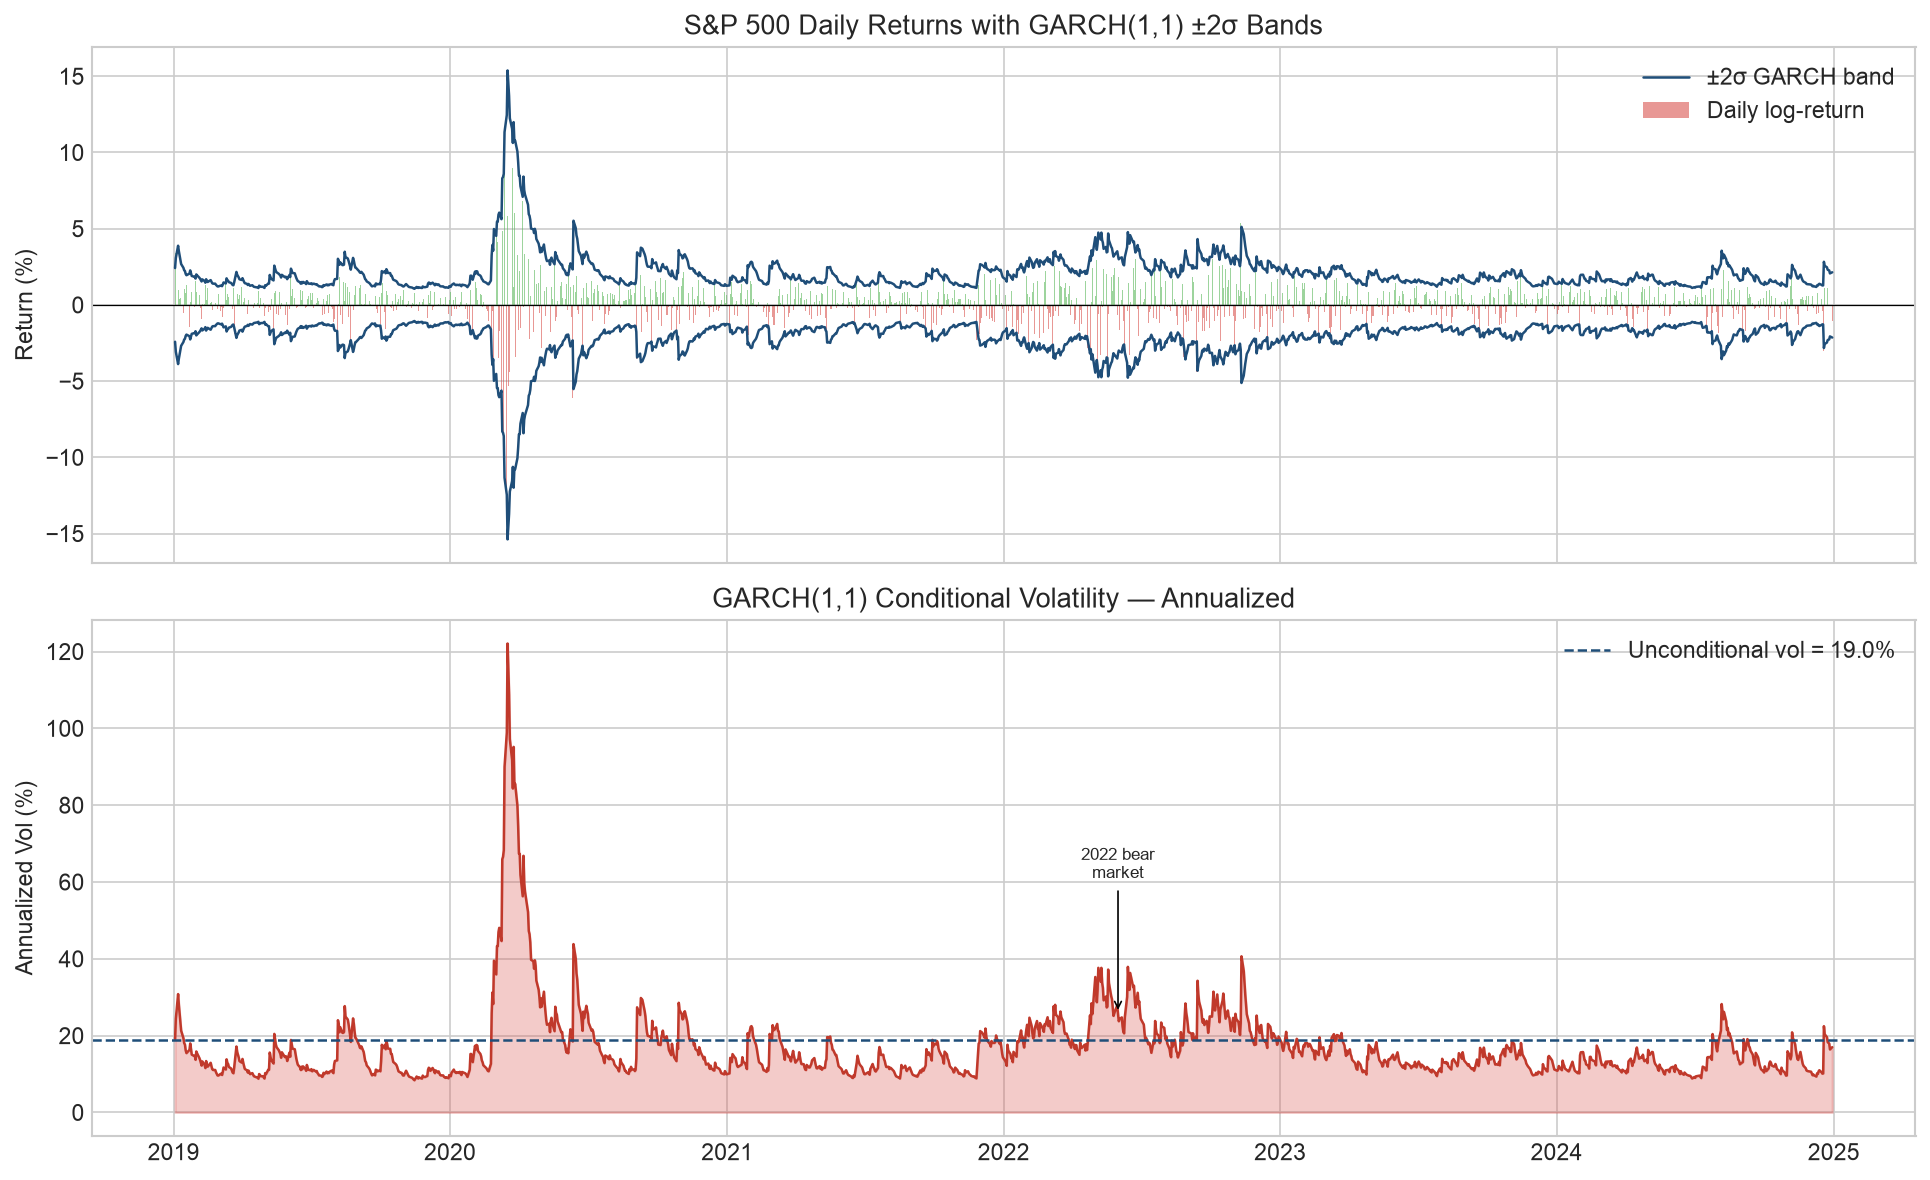

Volatility range (annualized): 8.4% – 122.1%
That is a 14.5x swing — constant-sigma models are badly wrong for most of the sample.


In [68]:
# ── Plot: time-varying GARCH volatility ──────────────────────────────────────
cond_vol = garch_fit.conditional_volatility  # daily sigma in %
cond_vol_ann = cond_vol * np.sqrt(252)       # annualized

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Returns
axes[0].bar(log_ret.index, log_ret.values,
            color=['#d9534f' if r < 0 else '#5cb85c' for r in log_ret.values],
            width=1, alpha=0.6, label='Daily log-return')
axes[0].plot(cond_vol.index, cond_vol.values * 2, color='#1f4e79',
             linewidth=1.2, label='±2σ GARCH band')
axes[0].plot(cond_vol.index, -cond_vol.values * 2, color='#1f4e79', linewidth=1.2)
axes[0].axhline(0, color='black', linewidth=0.6)
axes[0].set_title('S&P 500 Daily Returns with GARCH(1,1) ±2σ Bands')
axes[0].set_ylabel('Return (%)')
axes[0].legend(loc='upper right')

# Annualized vol
axes[1].fill_between(cond_vol_ann.index, cond_vol_ann.values,
                     alpha=0.3, color='#d9534f')
axes[1].plot(cond_vol_ann.index, cond_vol_ann.values,
             color='#c0392b', linewidth=1.2)
axes[1].axhline(unconditional_vol, color='#1f4e79', linestyle='--',
                linewidth=1.2, label=f'Unconditional vol = {unconditional_vol:.1f}%')
axes[1].set_title('GARCH(1,1) Conditional Volatility — Annualized')
axes[1].set_ylabel('Annualized Vol (%)')
axes[1].legend()

# Annotate key events
for date, label, ypos in [
    ('2020-03-01', 'COVID\ncrash', cond_vol_ann.max() * 0.9),
    ('2022-06-01', '2022 bear\nmarket', cond_vol_ann.max() * 0.5),
]:
    if pd.Timestamp(date) in cond_vol_ann.index:
        axes[1].annotate(label, xy=(pd.Timestamp(date), cond_vol_ann.loc[date:date].values[0]),
                         xytext=(pd.Timestamp(date), ypos),
                         fontsize=8, ha='center',
                         arrowprops=dict(arrowstyle='->', color='black', lw=0.8))

plt.tight_layout()
plt.show()

print(f'Volatility range (annualized): {cond_vol_ann.min():.1f}% – {cond_vol_ann.max():.1f}%')
print(f'That is a {cond_vol_ann.max()/cond_vol_ann.min():.1f}x swing — constant-sigma models are badly wrong for most of the sample.')

---
## Section 8 — Value at Risk and Expected Shortfall

We now turn the GARCH volatility forecast into a practical risk metric.

**Value at Risk (VaR):** the loss you should not exceed on a given day with probability (1−α).

Under Normal-GARCH:
$$\text{VaR}_{\alpha}(t) = -\Phi^{-1}(\alpha) \cdot \hat{\sigma}_t$$

**Expected Shortfall (ES / CVaR):** the *expected* loss given that VaR is breached. Always larger than VaR and more informative about tail risk.

$$\text{ES}_{\alpha}(t) = \frac{\phi(\Phi^{-1}(\alpha))}{\alpha} \cdot \hat{\sigma}_t$$

where φ is the standard normal PDF and Φ⁻¹ is the inverse CDF.

VaR is *time-varying* — it expands when GARCH says volatility is high, contracts when it's low. A constant-sigma VaR model is wrong in both directions.

In [69]:
# ── Compute VaR and ES ───────────────────────────────────────────────────────
CL_95 = 0.95
CL_99 = 0.99

z_95 = norm.ppf(1 - CL_95)  # ≈ -1.645
z_99 = norm.ppf(1 - CL_99)  # ≈ -2.326

# VaR (as a positive loss number)
var_95 = -z_95 * cond_vol
var_99 = -z_99 * cond_vol

# Expected Shortfall
es_95 = (norm.pdf(z_95) / (1 - CL_95)) * cond_vol
es_99 = (norm.pdf(z_99) / (1 - CL_99)) * cond_vol

# Align returns with conditional vol (cond_vol starts one period later)
common_idx = log_ret.index.intersection(cond_vol.index)
r_aligned  = log_ret.loc[common_idx]
var95_al   = var_95.loc[common_idx]
var99_al   = var_99.loc[common_idx]
es95_al    = es_95.loc[common_idx]
es99_al    = es_99.loc[common_idx]

# Breaches (return < −VaR)
breach_95 = r_aligned < -var95_al
breach_99 = r_aligned < -var99_al

T = len(r_aligned)
print(f'Total observations  : {T}')
print(f'\n95% VaR breaches    : {breach_95.sum()}  (expected {T*0.05:.1f})  = {breach_95.mean()*100:.2f}%')
print(f'99% VaR breaches    : {breach_99.sum()}  (expected {T*0.01:.1f})  = {breach_99.mean()*100:.2f}%')
print(f'\nAvg daily VaR 95%   : {var95_al.mean():.4f}%')
print(f'Avg daily VaR 99%   : {var99_al.mean():.4f}%')
print(f'Max daily VaR 95%   : {var95_al.max():.4f}%  (on {var95_al.idxmax().date()})')
print(f'Max daily VaR 99%   : {var99_al.max():.4f}%  (on {var99_al.idxmax().date()})')
print(f'\nAvg ES 95%          : {es95_al.mean():.4f}%  (≈{es95_al.mean()/var95_al.mean():.2f}× VaR 95%)')
print(f'Avg ES 99%          : {es99_al.mean():.4f}%  (≈{es99_al.mean()/var99_al.mean():.2f}× VaR 99%)')

Total observations  : 1508

95% VaR breaches    : 85  (expected 75.4)  = 5.64%
99% VaR breaches    : 27  (expected 15.1)  = 1.79%

Avg daily VaR 95%   : 1.7738%
Avg daily VaR 99%   : 2.5087%
Max daily VaR 95%   : 12.6500%  (on 2020-03-17)
Max daily VaR 99%   : 17.8911%  (on 2020-03-17)

Avg ES 95%          : 2.2244%  (≈1.25× VaR 95%)
Avg ES 99%          : 2.8742%  (≈1.15× VaR 99%)


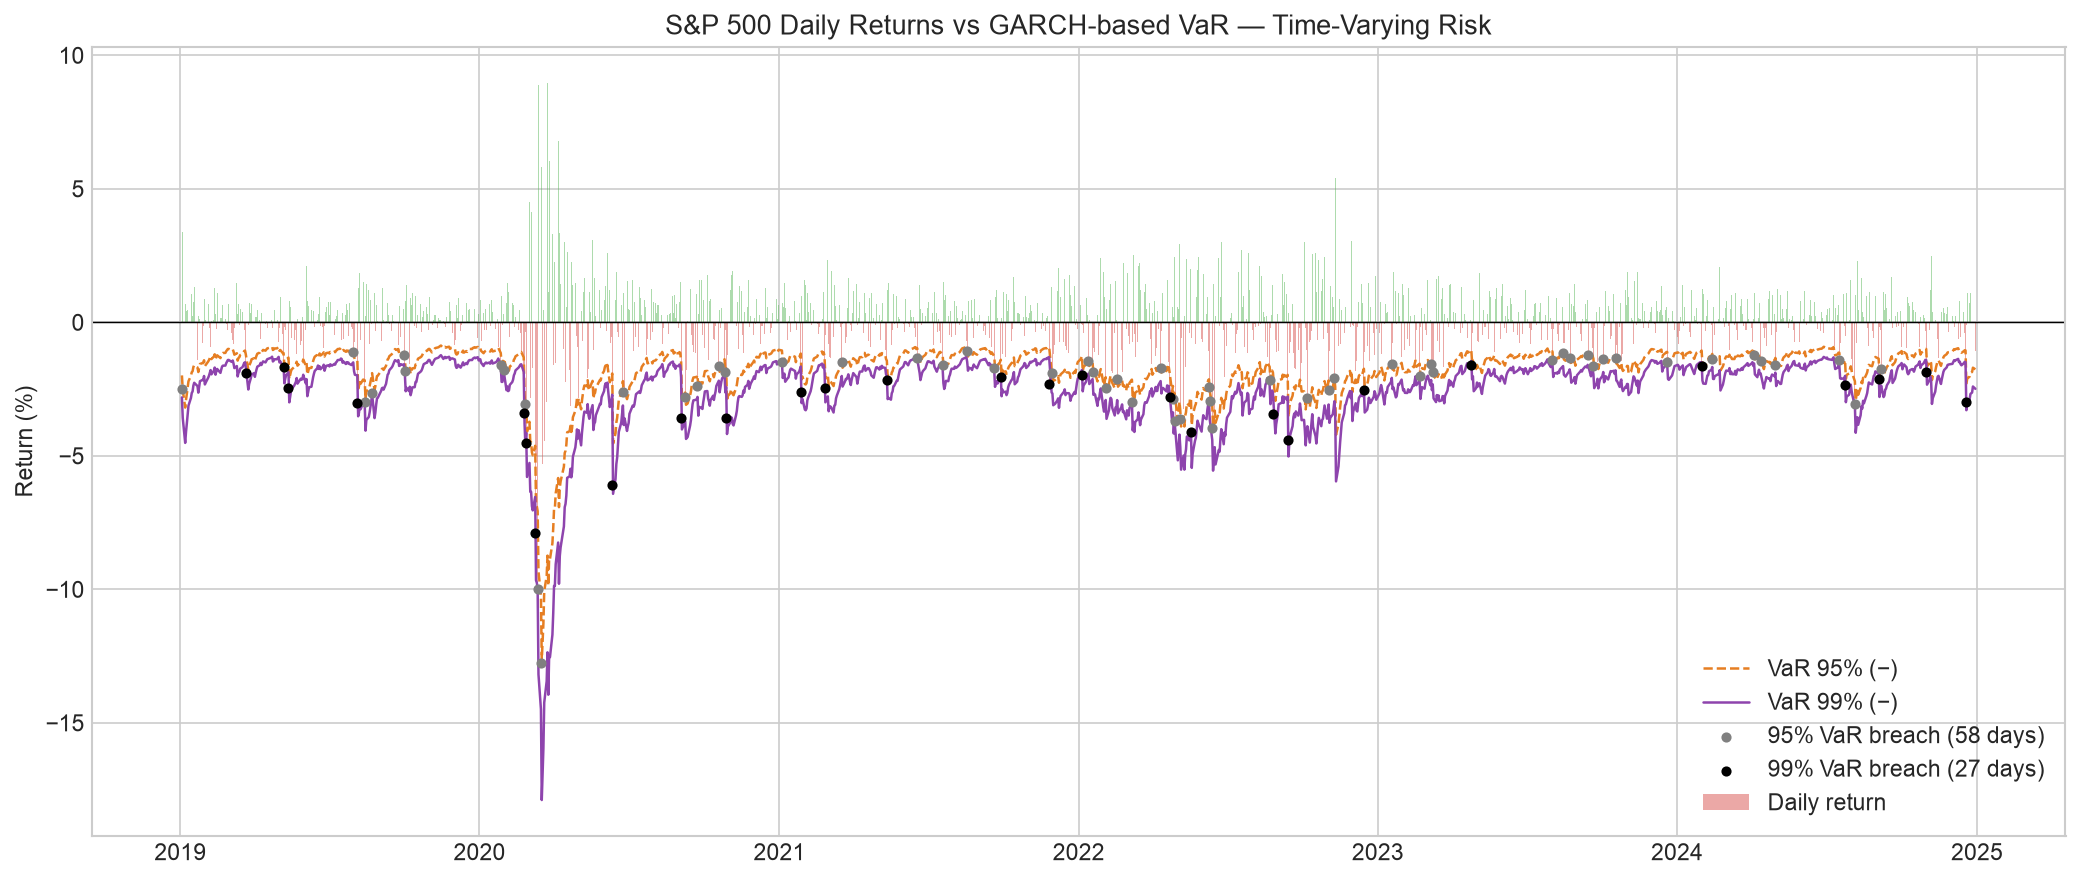

Key observation: the VaR lines widen dramatically during stress periods.
A constant-sigma model would have the same VaR line every day — wrong in both directions.


In [70]:
# ── Plot: returns vs VaR lines ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(r_aligned.index, r_aligned.values,
       color=['#d9534f' if r < 0 else '#5cb85c' for r in r_aligned.values],
       width=1, alpha=0.5, label='Daily return')

ax.plot(var95_al.index, -var95_al.values, color='#e67e22', linewidth=1.2,
        linestyle='--', label='VaR 95% (−)')
ax.plot(var99_al.index, -var99_al.values, color='#8e44ad', linewidth=1.2,
        label='VaR 99% (−)')

# Mark breaches — 95%-only breaches (gray) vs 99% breaches (black, the more severe subset)
breach_95_only = breach_95 & ~breach_99
breach_95_dates = r_aligned.index[breach_95_only]
breach_99_dates = r_aligned.index[breach_99]

ax.scatter(breach_95_dates, r_aligned.loc[breach_95_dates],
           color='gray', zorder=4, s=15, label=f'95% VaR breach ({breach_95_only.sum()} days)')
ax.scatter(breach_99_dates, r_aligned.loc[breach_99_dates],
           color='black', zorder=5, s=15, label=f'99% VaR breach ({breach_99.sum()} days)')

ax.axhline(0, color='black', linewidth=0.7)
ax.set_title('S&P 500 Daily Returns vs GARCH-based VaR — Time-Varying Risk')
ax.set_ylabel('Return (%)')
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

print('Key observation: the VaR lines widen dramatically during stress periods.')
print('A constant-sigma model would have the same VaR line every day — wrong in both directions.')

---
## Section 9 — Kupiec Backtest

We built a risk model. Now we test whether it is well-calibrated.

**Kupiec's Proportion of Failures (POF) test** asks: is the observed breach rate statistically consistent with the model's claimed confidence level?

H₀: The true failure probability = α (model is correctly calibrated)  
H₁: The true failure probability ≠ α

The test statistic:
$$\text{LR} = 2\left[N \ln\left(\frac{N/T}{\alpha}\right) + (T-N)\ln\left(\frac{1 - N/T}{1 - \alpha}\right)\right] \sim \chi^2_1$$

where T = total days, N = number of breaches, α = expected failure rate.

If LR > 3.841 (the χ²₁ critical value at 5% significance), we reject the model.  
This is the same test implemented in the Excel Part 1, now running on real data with MLE-estimated GARCH.

In [71]:
def kupiec_pof_test(returns, var_series, confidence_level):
    """
    Kupiec (1995) Proportion of Failures backtest.
    
    Parameters
    ----------
    returns          : pd.Series — actual return series (%)
    var_series       : pd.Series — VaR estimates (positive number, % loss threshold)
    confidence_level : float — e.g. 0.95 for 95% VaR
    
    Returns
    -------
    dict with test statistics and verdict
    """
    alpha = 1 - confidence_level          # expected failure rate
    T     = len(returns)                  # total observations
    N     = int((returns < -var_series).sum())  # actual breaches
    p_hat = N / T                         # observed failure rate

    # Likelihood ratio statistic
    if N == 0:
        # Edge case: no breaches at all
        lr = -2 * T * np.log(1 - alpha)
    elif N == T:
        lr = -2 * T * np.log(alpha)
    else:
        lr = 2 * (
            N * np.log(p_hat / alpha) +
            (T - N) * np.log((1 - p_hat) / (1 - alpha))
        )

    cv    = chi2.ppf(0.95, df=1)          # 3.841
    pval  = 1 - chi2.cdf(lr, df=1)

    return {
        'Confidence Level'        : f'{confidence_level*100:.0f}%',
        'Total Obs (T)'           : T,
        'Actual Breaches (N)'     : N,
        'Expected Breaches'       : round(T * alpha, 1),
        'Observed Failure Rate'   : f'{p_hat*100:.4f}%',
        'Expected Failure Rate'   : f'{alpha*100:.2f}%',
        'LR Statistic'            : round(lr, 4),
        'Critical Value (χ²₁,5%)': round(cv, 3),
        'p-value'                 : round(pval, 4),
        'Reject H₀?'             : 'YES ✗' if lr > cv else 'NO ✓',
        'Model Valid?'            : 'No' if lr > cv else 'Yes ✓'
    }

# Run for both VaR levels
test_95 = kupiec_pof_test(r_aligned, var95_al, 0.95)
test_99 = kupiec_pof_test(r_aligned, var99_al, 0.99)

kupiec_table = pd.DataFrame({'VaR 95%': test_95, 'VaR 99%': test_99})
print('KUPIEC POF BACKTEST RESULTS')
print(kupiec_table.to_string())

print('\nInterpretation:')
for test, label in [(test_95, '95%'), (test_99, '99%')]:
    verdict = 'PASS' if test['Reject H₀?'] == 'NO ✓' else 'FAIL'
    print(f'  VaR {label}: LR = {test["LR Statistic"]} vs critical = 3.841 → {verdict}')

KUPIEC POF BACKTEST RESULTS
                         VaR 95%  VaR 99%
Confidence Level             95%      99%
Total Obs (T)               1508     1508
Actual Breaches (N)           85       27
Expected Breaches           75.4     15.1
Observed Failure Rate    5.6366%  1.7905%
Expected Failure Rate      5.00%    1.00%
LR Statistic               1.238   7.7087
Critical Value (χ²₁,5%)    3.841    3.841
p-value                   0.2659   0.0055
Reject H₀?                  NO ✓    YES ✗
Model Valid?               Yes ✓       No

Interpretation:
  VaR 95%: LR = 1.238 vs critical = 3.841 → PASS
  VaR 99%: LR = 7.7087 vs critical = 3.841 → FAIL


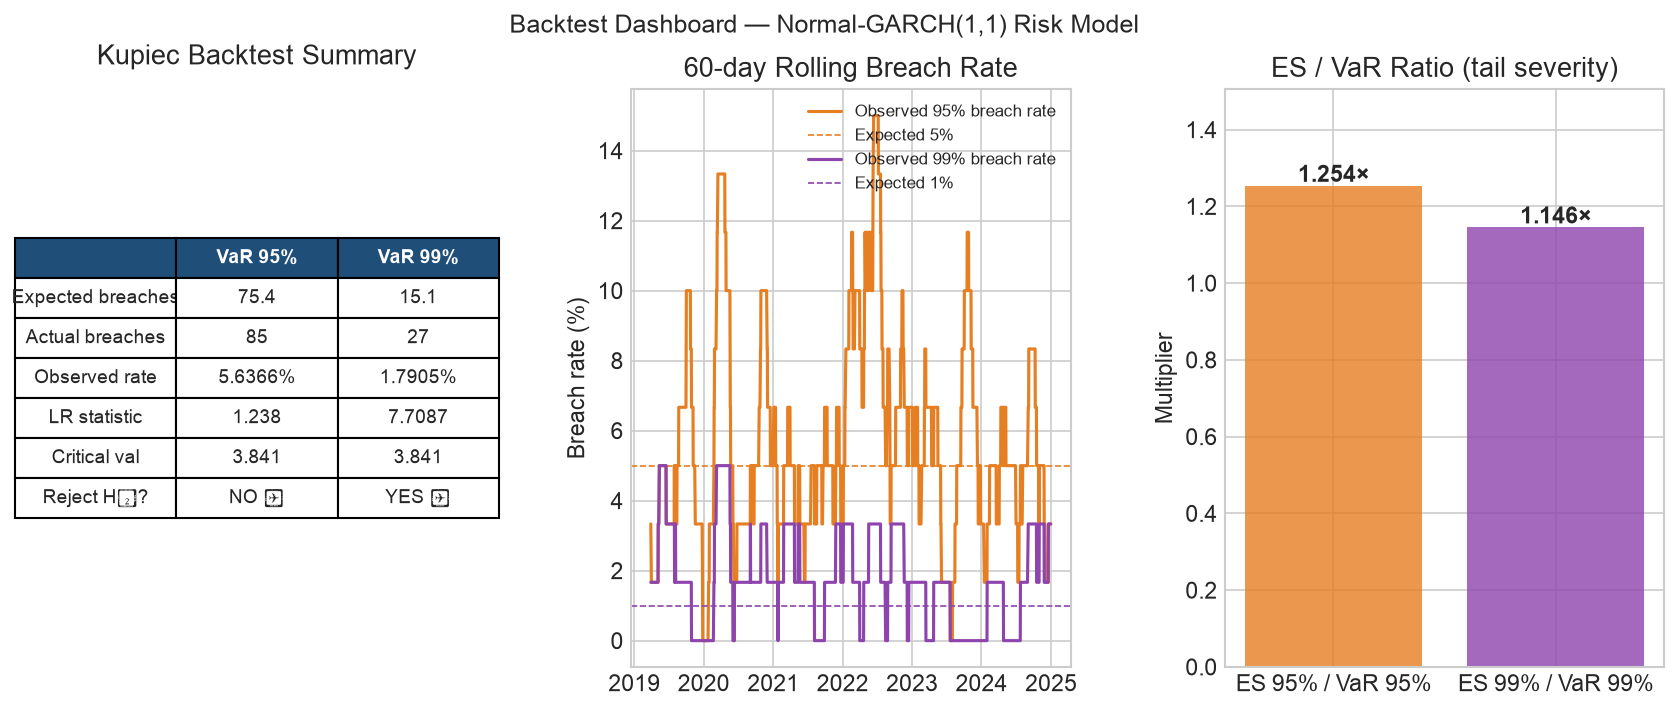

In [72]:
# ── Summary dashboard ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# Left: breach calendar
ax1 = fig.add_subplot(gs[0, 0])
ax1.axis('off')
rows = [
    ['', 'VaR 95%', 'VaR 99%'],
    ['Expected breaches', str(test_95['Expected Breaches']), str(test_99['Expected Breaches'])],
    ['Actual breaches',   str(test_95['Actual Breaches (N)']),    str(test_99['Actual Breaches (N)'])],
    ['Observed rate',     test_95['Observed Failure Rate'],  test_99['Observed Failure Rate']],
    ['LR statistic',      str(test_95['LR Statistic']),       str(test_99['LR Statistic'])],
    ['Critical val',      '3.841',                            '3.841'],
    ['Reject H₀?',       test_95['Reject H₀?'],              test_99['Reject H₀?']],
]
tbl = ax1.table(cellText=rows[1:], colLabels=rows[0], loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.1, 1.6)
for j in range(3):
    tbl[0, j].set_facecolor('#1f4e79')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
ax1.set_title('Kupiec Backtest Summary', pad=12)

# Middle: rolling breach rate vs expected
ax2 = fig.add_subplot(gs[0, 1])
window = 60
roll_breach_95 = breach_95.rolling(window).mean() * 100
roll_breach_99 = breach_99.rolling(window).mean() * 100
ax2.plot(roll_breach_95.index, roll_breach_95.values,
         label='Observed 95% breach rate', color='#e67e22')
ax2.axhline(5, color='#e67e22', linestyle='--', linewidth=0.8, label='Expected 5%')
ax2.plot(roll_breach_99.index, roll_breach_99.values,
         label='Observed 99% breach rate', color='#8e44ad')
ax2.axhline(1, color='#8e44ad', linestyle='--', linewidth=0.8, label='Expected 1%')
ax2.set_title(f'{window}-day Rolling Breach Rate')
ax2.set_ylabel('Breach rate (%)')
ax2.legend(fontsize=8)

# Right: VaR multipliers (ES/VaR ratio)
ax3 = fig.add_subplot(gs[0, 2])
mult_95 = es95_al.mean() / var95_al.mean()
mult_99 = es99_al.mean() / var99_al.mean()
bars = ax3.bar(['ES 95% / VaR 95%', 'ES 99% / VaR 99%'],
               [mult_95, mult_99],
               color=['#e67e22', '#8e44ad'], alpha=0.8)
for bar, val in zip(bars, [mult_95, mult_99]):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}×', ha='center', fontweight='bold')
ax3.set_title('ES / VaR Ratio (tail severity)')
ax3.set_ylabel('Multiplier')
ax3.set_ylim(0, max(mult_95, mult_99) * 1.2)

plt.suptitle('Backtest Dashboard — Normal-GARCH(1,1) Risk Model', fontsize=12)
plt.tight_layout()
plt.show()

---
## Section 10 — Key Takeaways and Where to Go Next

### What this two-part series covered

| Concept | Part 1 (Excel) | Part 2 (Python) |
|---|---|---|
| Log-returns vs prices | ✓ Build formula | ✓ Pull real data, see actual distribution |
| Stylized facts | ✓ Simulated — intuition | ✓ Real data — pronounced fat tails, proper skewness |
| Stationarity | ✓ Visual proof | ✓ ADF test — formal hypothesis test |
| ACF | ✓ Full treatment | ✓ Confirmed on real data |
| PACF | ✗ Not covered | ✓ Introduced — critical for AR order |
| ARIMA selection | ✗ Hardcoded order | ✓ AIC/BIC grid search |
| GARCH estimation | ✗ Parameters set manually | ✓ MLE via `arch` library |
| VaR / ES | ✓ Formula + fixed params | ✓ Time-varying from MLE-fitted GARCH |
| Kupiec test | ✓ Implemented | ✓ On real data with real fitted model |

### The one honest limitation of this model

The Normal-GARCH we fitted assumes standardized returns are normally distributed. The fat tails we saw in Section 2 (excess kurtosis) mean the normal assumption underestimates tail risk. The Kupiec test may still pass, but expect more breaches than predicted during severe stress.

**The fix:** replace `dist='Normal'` with `dist='t'` in the arch_model call. The t-distribution has heavier tails and the degrees-of-freedom parameter is estimated from the data. This is the standard upgrade.

### Natural next steps

1. **Student-t GARCH** — swap `dist='Normal'` for `dist='t'` and re-run the backtest. The breach rates should improve.
2. **GJR-GARCH (Glosten-Jagannathan-Runkle)** — adds an asymmetry term so negative returns raise variance more than positive returns of the same size. This is the leverage effect and it is clearly present in equity data.
3. **EGARCH** — another asymmetric GARCH variant, parameterized in log-variance so stationarity is guaranteed.
4. **Rolling window backtest** — instead of in-sample VaR, re-estimate GARCH each month and test the out-of-sample forecast.
5. **Multi-asset: DCC-GARCH** — extend to a portfolio of assets, model time-varying correlations, and build a proper covariance matrix for portfolio risk.

In [73]:
# ── Bonus: Student-t GARCH for comparison ────────────────────────────────────
print('Fitting GARCH(1,1) with Student-t innovations (heavier tails)...')

garch_t_spec = arch_model(
    log_ret, vol='Garch', p=1, q=1,
    dist='t',        # Student-t distribution
    mean='Constant'
)
garch_t_fit = garch_t_fit = garch_t_spec.fit(disp='off')

nu = garch_t_fit.params.get('nu', None)  # degrees of freedom
params_t = garch_t_fit.params

from scipy.stats import t as t_dist

cond_vol_t = garch_t_fit.conditional_volatility
common_t   = log_ret.index.intersection(cond_vol_t.index)
r_t        = log_ret.loc[common_t]
vol_t      = cond_vol_t.loc[common_t]

if nu is not None:
    # t-distribution VaR quantile — must apply sqrt((nu-2)/nu) scaling.
    # The arch library uses a standardized Student-t with unit variance, so
    # conditional_volatility IS the true conditional std dev (sigma_t).
    # scipy.stats.t.ppf gives quantiles for raw t(nu) with variance nu/(nu-2).
    # Scaling by sqrt((nu-2)/nu) converts to the unit-variance version that
    # matches arch's innovation convention.
    scale = np.sqrt((nu - 2) / nu)
    z_95_t = t_dist.ppf(0.05, df=nu) * scale
    z_99_t = t_dist.ppf(0.01, df=nu) * scale
    var_95_t = -z_95_t * vol_t
    var_99_t = -z_99_t * vol_t

    test_95_t = kupiec_pof_test(r_t, var_95_t, 0.95)
    test_99_t = kupiec_pof_test(r_t, var_99_t, 0.99)

    print(f'\nStudent-t degrees of freedom (ν): {nu:.2f}')
    print(f'(ν → ∞ converges to Normal; ν ≈ 4–8 typical for daily equity returns)')
    col_header = '{:<22} {:<18} {:<18} {}'.format('Model', 'VaR 95% LR', 'VaR 99% LR', 'AIC')
    print('\n' + col_header)
    print('-' * 70)
    print(f'{"Normal GARCH":<22} {test_95["LR Statistic"]:<18} {test_99["LR Statistic"]:<18} {garch_fit.aic:.2f}')
    print(f'{"Student-t GARCH":<22} {test_95_t["LR Statistic"]:<18} {test_99_t["LR Statistic"]:<18} {garch_t_fit.aic:.2f}')
    print(f'\nLower LR → better calibrated. Critical value = 3.841 → reject model if LR > 3.841')
    print(f'Lower AIC → better overall model fit.')
else:
    print('Note: nu parameter not found — check arch library version.')

Fitting GARCH(1,1) with Student-t innovations (heavier tails)...

Student-t degrees of freedom (ν): 6.66
(ν → ∞ converges to Normal; ν ≈ 4–8 typical for daily equity returns)

Model                  VaR 95% LR         VaR 99% LR         AIC
----------------------------------------------------------------------
Normal GARCH           1.238              7.7087             4223.60
Student-t GARCH        2.1083             0.9509             4157.74

Lower LR → better calibrated. Critical value = 3.841 → reject model if LR > 3.841
Lower AIC → better overall model fit.
